In [1]:
# uncomment this line if you need to install pyphyschemtools
# (remove "# " - don't forget to remove the empty space)
# !pip install pynanomatbuilder
# !pip install --index-url https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ pyNanoMatBuilder==0.1.0

# Optional: only necessary if you want to visualize 3D structures directly within the notebook.
# !pip install pyphyschemtools

<div class="rqT", title="📥 README first">

[**Click here: Local (cloning) *vs*. Google Colab**](./colab_vs_local.md)

if you choose a Google Colab cloud session, click on this icon (unless *you are already* in Google Colab):

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpoteau/pyNanoMatBuilder/blob/main/pyNMB-examples.ipynb)

</div>

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



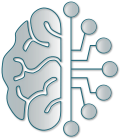

**Environment initialized:** Saturday 14 March 2026, 14:20:03 on localhost.localdomain

In [48]:
# development purpose only. Comment in google colab
%load_ext autoreload
%autoreload 2
#------------------------------

##################
# Initialization #
##################
import pyNanoMatBuilder as pyNMB
pyNMB.init()

# Introduction 
</div>


<div class="intro">
    
**pyNanoMatBuilder** is a building tool for generating **3D structures of crystalline nanoparticles (NPs)** of various **shapes** and **sizes**, based on **user-defined compounds** either by name, e.g., "Fe bcc" (cf *data.py* and *cif_database* to see all available compounds and their acronyms) or from your CIF files directly (in the folder *userDefCifs*).

This notebook is a general demonstration of what is possible to do with pyNanoMatBuilder and shows all the shapes you can create, from Wulff constructions to magic number structures. 

Here's the content:
- **Creation of XYZ, CIF files and Jmol scripts** of the nanoparticles from all shape classes (cf. image above). Each class has its own parameters, so do not hesitate to read their documentation.

- **Geometry optimization** using ASE and pyNanoMatBuilder files.

- **More analysis tools** (symmetry, coordination numbers, etc.)

- **Bibliography**

*Note: If you directly want to create a database containing the NP structures and their scattering data, please refer to the `MakeNPsDatabase.ipynb` notebook.*

</div>


## Common Parameters

<div class="intro">
Key parameters available across all nanoparticle classes:

| Parameter | Type | Description |
|-----------|------|-------------|
| **`postAnalyzis`** | bool | Enable detailed analysis including unit cell properties, symmetry analysis, moment of inertia, surface/core informations, precise size informations |
| **`noOutput`** | bool | Suppress console output |
| **`skipSymmetryAnalyzis`** | bool | Skip symmetry calculations (useful for faster execution)  (if set to False, requires `postAnalyzis = True`) |
| **`jmolCrystalShape`** | bool | Generate Jmol visualization scripts (if set to True, requires `postAnalyzis = True`) |
| **`aseView`** | bool | Display structure using ASE viewer |
| **`thresholdCoreSurface`** | float | Threshold for core/surface atom classification |

</div>

## How to? Workflow Guides

### Quick usage

<div class="intro">

#### Importation of the necessary classes

First, import a core builder **and** the utility module:

```python
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu
```

#### Available core builders

The library is organized into specialized classes depending on the crystalline nature and geometric complexity of the nanoparticle you wish to build:

| Class | Abbreviation | Core Shapes & Capabilities |
| :--- | :--- | :--- |
| **`crystalNPs`** | `cyNP` | **Single Crystals**: Spheres, ellipsoids, parallelepipeds, hollow shapes, and user- or pre-defined **Wulff constructions**. |
| **`platonicNPs`** | `pNP` | **Platonic Solids**: Icosahedron, octahedron, dodecahedron, tetrahedron, and cubes. |
| **`archimedeanNPs`** | `aNP` | **Archimedean Solids**: Cuboctahedron, truncated decahedron, truncated octahedron, rhombic dodecahedron, and dihedral rhombic dodecahedron. |
| **`johnsonNPs`** | `jNP` | **Johnson Solids & Decahedra**: Trigonal/pentagonal bipyramids, Ino decahedron, and Marks decahedron. |
| **`otherNPs`** | `oNP` | **Special Geometries**: Trigonal platelets and other non-standard architectures. |

All currently available shapes are summarized in this figure:

<img src="https://github.com/rpoteau/pyNanoMatBuilder/raw/main/pyNanoMatBuilder/resources/figs/pnmbAvailableStructures.png" style="margin-left:auto; margin-right:auto; display: block; width:1200px" id="img_pNMBAS" alt="Structures available in pyNMB"/>

#### Generating a Nanoparticle

Instantiate the `pyNMB.Crystal` object to build your structure. **Note that the geometry creation and symmetry analysis are performed immediately upon instantiation.**

```python
# Define parameters
sphere_diameter = [6] # Target diameter in nm
# Instantiate the Crystal object (Au fcc sphere)
AuNP = cyNP.Crystal(
    "Au fcc",
    size=sphere_diameter, 
    shape="sphere", 
    thresholdCoreSurface=1, 
    skipSymmetryAnalyzis=False, 
    noOutput=False
)
```

* **Silent Mode**: Set `noOutput=True` for a silent execution.
* **Performance**: For very large structures (typically > 6 nm), set `skipSymmetryAnalyzis=True` to bypass heavy point-group calculations.

**Available Object Attributes**
Once instantiated, the object (e.g., `AuNP`) contains several key attributes that you can access or save:

| Attribute | Description |
| :--- | :--- |
| **.NP** | An ASE `Atoms` object containing the final shaped nanoparticle. |
| **.NPcs** | The Core/Surface model (where core atoms are labeled as 'No' for visualization). |
| **.cif** | The ASE `Atoms` object of the original unit cell. |
| **.sc** | The ASE `Atoms` object of the supercell used for shaping. |
| **.jMolCS** | A string containing the Jmol visualization script for facets (unless `jmolCrystalShape=False`) |

#### Exporting Results

The library provides a unified `write()` utility. It is **mandatory** to use the standard `.xyz`, `.cif`, or `.script` suffixes; otherwise, the utility will not be able to determine the correct format and may fail or lose data.

```python
# Example
pyNMBu.write("coords/SphericalAuNP.xyz", AuNP.NP)
```

* **Atomic Coordinates (`.xyz`)**: Standard geometry file.
* **Core/Surface Model**: A specialized `.xyz` where core atoms are labeled as the element **'No'** (Nobelium). In Jmol, these appear in a distinct magenta color, making the core-shell organization immediately visible.
* **Crystallography (`.cif`)**:
    * **Base Unit Cell**: The original crystal structure used as the building block.
    * **Supercell**: The expanded cell used for shaping the NP (automatically calculated based on the target size).

#### External Jmol Visualization

To visualize surface faceting and crystalline organization:

1.  Open Jmol and load your resulting `.xyz` or `.cif` file.
2.  In the Jmol console, load the generated visualization script:
    ```bash
    script "path_to_folder/your_np_name.script"
    ```
    *This script overlays the geometric "envelope" (facets) onto your atomic structure.*

<div class="rqE">
    
**Note on Core/Surface ID**: The 'No' (Nobelium) label is a visualization trick. If you are using these files for DFT calculations or MD simulations, remember to convert the 'No' atoms back to their original element (e.g., 'Au') using a text editor or the ASE `atoms.set_chemical_symbols()` method.
</div>


#### Internal Visualization

If you are working in a Jupyter Notebook or Google Colab, you can visualize the nanoparticle internally (without Jmol) by two ways
- either by using the `molView` class of the `pyphyschemtools` library. This provides an interactive 3D view directly in your cell output

```python
!pip install pyphyschemtools # if necessary
from pyphyschemtools import molView
m = molView(AuNP.NP,source="ase", w=600,h=600)
```

<br>
<div class="rqE">

`molView` is unable to interpret jmol scripts.
</div>

- by setting `aseView=True` (default is False). For crystal-based shapes, the unitcell, the supercell, and the resulting facetted single crystal will all be displayed

```python
AuNP = cyNP.Crystal(
    "Au fcc",
    size=[3], 
    shape="sphere", 
    thresholdCoreSurface=1, 
    skipSymmetryAnalyzis=False, 
    noOutput=False,
    aseView=True,
)
```

</div>

### Detailed documentation

<div class="intro">
    
You can either enter `cyNP.Crystal?` to see the docstring or consult the [on-line API reference](https://pynanomatbuilder.readthedocs.io/en/latest/).
</div>

In [5]:
from pyNanoMatBuilder import crystalNPs as cyNP
cyNP.Crystal?

Init signature:
cyNP.Crystal(
    crystal: str = 'Au',
    scaleDmin2: float = None,
    setSymbols2: numpy.ndarray = None,
    userDefCif: str = None,
    shape: str = 'sphere',
    size: float = None,
    directionsPPD: numpy.ndarray = None,
    buildPPD: str = 'xyz',
    directionWire: float = None,
    directionCylinder: float = None,
    refPlaneWire: float = None,
    nRotWire: int = 6,
    hollow_sphere_diameter: float = None,
    surfacesWulff: numpy.ndarray = None,
    eSurfacesWulff: numpy.ndarray = None,
    sizesWulff: numpy.ndarray = None,
    symWulff: bool = True,
    jmolCrystalShape: bool = True,
    aseSymPrec: float = 0.0001,
    pbc: bool = False,
    threshold: float = 0.001,
    dbFolder: str = None,
    postAnalyzis: bool = True,
    aseView: bool = False,
    thresholdCoreSurface: float = 1.0,
    skipSymmetryAnalyzis: bool = False,
    noOutput: bool = False,
    calcPropOnly: bool = False,
)
Docstring:     
A class for generating XYZ and CIF files of crystalli

# Crystal structure-based shapes


In [115]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define parameters
sphere_diameter = [3] # Target diameter in nm
# Instantiate the Crystal object (Au fcc sphere)
AuNP = cyNP.Crystal(
    "Au fcc",
    size=sphere_diameter,
    shape="sphere",
    thresholdCoreSurface=1,
    skipSymmetryAnalyzis=False,
    noOutput=False
)

# Save the results in various formats
# The 'write' utility automatically creates the 'coords/' directory, if it does not exist
pyNMBu.write("coords/SphericalAuNP.xyz", AuNP.NP)                # Main coordinates
pyNMBu.write("coords/SphericalAuNP_CoreSurface.xyz", AuNP.NPcs)  # Core/surface model
pyNMBu.write("coords/SphericalAuNP.script", AuNP.jMolCS)         # JMOL visualization script

# Save unitcells
pyNMBu.write("coords/SphericalAuNP_uc.cif", AuNP.cif)            # The base unitcell
pyNMBu.write("coords/SphericalAuNP_sc.cif", AuNP.sc)             # The supercell used for shaping

# Internal visualization
from pyphyschemtools import molView
mv = molView(AuNP.cif, source='ase', w=400,h=400)
AuNPc = AuNP.NP.copy()
AuNPc.center()
mv2 = molView.view_grid([AuNP.NP, AuNPc], n_cols = 2, source="ase", titles= ["centered at O", "centered in the middle of the unit cell"], w=600, h =600, detect_BondOrders=False)


CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Making a sphere with target radius = 1.500 nm


First making a 5x5x5 supercell
Making a 2x2x2 supercell of the supercell
       = 10x10x10 supercell
Center of Mass: ['19.37', '19.37', '19.37'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 4000
Duration : 00:00:00 004ms


Measured radius = 13.25 Å
Duration : 00:00:00 017ms
Total number of atoms = 820


Bravais lattice: CUB(a=4.07825)
Chemical formula: Au4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 4.078 Å, b: 4.078 Å, c: 4.078 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 67.830 Å3


...

276 atoms lie in the plane(s)
Duration : 00:00:00 004ms


diameters of the circumscribed sphere: 2.65 nm
diameters of the inscribed sphere: 2.65 nm


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Spheres

<div class="intro">
    
**The size parameter for the sphere is simply the diameter [d] in nm. Few examples are presented.**

</div>

### Au NPs

In [7]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a sphere with a diameter of ~ 4 nm (4 nm will be the target size, the measured size will be slightly different due to compound cristalline organization)
sphere_diameter = [4] # diameter in nm
AuNP = cyNP.Crystal("Au fcc",size = sphere_diameter, shape = "sphere", thresholdCoreSurface = 1, skipSymmetryAnalyzis = False, noOutput = False)

# Save the files (XYZ, JMOL script, CIF) of the NP and also the core/surface model
pyNMBu.write("coords/SphericalAuNP.xyz", AuNP.NP) # XYZ file with the 
pyNMBu.write("coords/SphericalAuNP_CoreSurface.xyz", AuNP.NPcs) # XYZ file of the core/surface model
AuNP.NP.center()
pyNMBu.write("coords/SphericalAuNP.cif", AuNP.NP) # CIF file
pyNMBu.write("coords/SphericalAuNP.script", AuNP.jMolCS) # JMOL script if postAnalyzis and jmolCrystalShape are True (they are by default)
pyNMBu.write("coords/SphericalAuNP2.cif", AuNP.cif) # CIF file


CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Making a sphere with target radius = 2.000 nm


First making a 5x5x5 supercell
Making a 2x2x2 supercell of the supercell
       = 10x10x10 supercell
Center of Mass: ['19.37', '19.37', '19.37'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 4000
Duration : 00:00:00 006ms


Measured radius = 19.37 Å
Duration : 00:00:00 054ms
Total number of atoms = 1956


Bravais lattice: CUB(a=4.07825)
Chemical formula: Au4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 4.078 Å, b: 4.078 Å, c: 4.078 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 67.830 Å3


...

Moments of inertia = 61223006.74 61223006.74 61223006.74 amu.Å2
Moments of inertia / M = 158.91 158.91 158.91 amu.Å2
Moments of inertia with mass=1/M = 158.91 158.91 158.91 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Td
Rotational Symmetry Number = 12
Duration : 00:00:01 848ms


Found:
  - 132 vertices
  - 260 simplices
Duration : 00:00:00 003ms


448 atoms lie in the plane(s)
Duration : 00:00:00 005ms


diameters of the circumscribed sphere: 3.87 nm
diameters of the inscribed sphere: 3.87 nm


### Ru

In [8]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a Ruthenium sphere of a diameter ~ 5 nm
RuNP = cyNP.Crystal("Ru hcp", shape= "sphere", size = [2]) # Other parameters set as default, see documentation

# Save the files( XYZ, JMOL script, CIF) and the core/surface model
pyNMBu.write("coords/SphericalRuNP.xyz", RuNP.NP) 
pyNMBu.write("coords/SphericalRuNP.cif", RuNP.cif) 
pyNMBu.write("coords/SphericalRuNP_sc.cif", RuNP.sc) 
RuNP.NP.center()
pyNMBu.write("coords/SphericalRuNP.cif", RuNP.NP)
pyNMBu.write("coords/SphericalAuNP_sc.cif", RuNP.sc)
pyNMBu.write("coords/SphericalRuNP.script", RuNP.jMolCS) # JMOL script
pyNMBu.write("coords/SphericalRuNP_CoreSurface.xyz", RuNP.NPcs)  

CIF parameters for Ru hcp found in cod9008513-Ru_hcp.cif


Making a sphere with target radius = 1.000 nm


First making a 7x7x5 supercell
Making a 2x2x2 supercell of the supercell
       = 14x14x10 supercell
Center of Mass: ['9.46', '16.39', '21.41'] Å
Now translating the supercell to origin
Center of Mass after translation: [-6.75972497e-06  1.17081871e-05  1.04793084e-15] Å
Total number of atoms = 3920
Duration : 00:00:00 004ms


Measured radius = 9.63 Å
Duration : 00:00:00 018ms
Total number of atoms = 300


Bravais lattice: HEX(a=2.70389, c=4.28168)
Chemical formula: Ru2
Crystal family = hexagonal (lattice system = hexagonal)
Name = primitive hexagonal (Pearson symbol = hP)
Variant names = ['HEX']

From ase: space group number = 194      Hermann-Mauguin symbol for the space group = P6_3/mmc

a: 2.704 Å, b: 2.704 Å, c: 4.282 Å. (c/a = 1.584)
α: 90.000 °, β: 90.000 °, γ: 120.000 °

Volume: 27.110 Å3


...

Moments of inertia = 1182279.85 1192867.39 1192867.39 amu.Å2
Moments of inertia / M = 38.99 39.34 39.34 amu.Å2
Moments of inertia with mass=1/M = 38.99 39.34 39.34 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Th
Rotational Symmetry Number = 6
Duration : 00:00:00 096ms


Found:
  - 72 vertices
  - 140 simplices
Duration : 00:00:00 002ms


144 atoms lie in the plane(s)
Duration : 00:00:00 003ms


diameters of the circumscribed sphere: 1.93 nm
diameters of the inscribed sphere: 1.93 nm


### TiO2

In [9]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a TiO2 sphere of a diameter ~ 3 nm
TiO2rNP = cyNP.Crystal("TiO2 rutile", size= [3], thresholdCoreSurface = 1, skipSymmetryAnalyzis = False)

# Save the files( XYZ, JMOL script, CIF) and the core/surface model
pyNMBu.write("coords/SphericalTiO2rNP_cif.cif", TiO2rNP.cif)
pyNMBu.write("coords/SphericalTiO2ruNP_sc.cif", TiO2rNP.sc)
TiO2rNP.NP.center()
pyNMBu.write("coords/SphericalTiO2rNP.cif", TiO2rNP.NP)
pyNMBu.write("coords/SphericalTiO2rNP.xyz", TiO2rNP.NP)
pyNMBu.write("coords/SphericalTiO2rNP_CoreSurface.xyz", TiO2rNP.NPcs)
pyNMBu.write("coords/SphericalTiO2rNP.script", TiO2rNP.jMolCS)

CIF parameters for TiO2 rutile found in cod9015662-TiO2-rutile.cif


Making a sphere with target radius = 1.500 nm


First making a 4x4x7 supercell
Making a 2x2x2 supercell of the supercell
       = 8x8x14 supercell
Center of Mass: ['17.69', '17.69', '19.97'] Å
Now translating the supercell to origin
Center of Mass after translation: [-0.68830726 -0.68830726 -0.739675  ] Å
Total number of atoms = 5376
Duration : 00:00:00 004ms


Measured radius = 14.05 Å
Duration : 00:00:00 023ms
Total number of atoms = 1363


Bravais lattice: TET(a=4.5937, c=2.9587)
Chemical formula: O4Ti2
Crystal family = tetragonal (lattice system = tetragonal)
Name = primitive tetragonal (Pearson symbol = tP)
Variant names = ['TET']

From ase: space group number = 136      Hermann-Mauguin symbol for the space group = P4_2/mnm

a: 4.594 Å, b: 4.594 Å, c: 2.959 Å. (c/a = 0.644)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 62.435 Å3


...

Moments of inertia = 3253693.96 3292973.01 3302682.67 amu.Å2
Moments of inertia / M = 89.46 90.54 90.81 amu.Å2
Moments of inertia with mass=1/M = 89.53 90.31 90.57 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: D1d
Rotational Symmetry Number = 1
Duration : 00:00:01 754ms


Found:
  - 146 vertices
  - 288 simplices
Duration : 00:00:00 003ms


409 atoms lie in the plane(s)
Duration : 00:00:00 005ms


diameters of the circumscribed sphere: 2.81 nm
diameters of the inscribed sphere: 2.81 nm


### load an external cif file
**You can try it out with your own CIF files, just place them in the userDefCifs folder**

In [10]:
# imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# This time let's use CIF files from the user (put your CIF files in userDefCifs)
Fe2NNP = cyNP.Crystal(userDefCif="./userDefCifs/Fe2N-zeta-1668016.cif", shape = "sphere", size = [2], skipSymmetryAnalyzis = True)

# Save the files( XYZ, JMOL script, CIF) and the core/surface model
pyNMBu.write("coords/SphericalFe2N_NP_cif.cif", Fe2NNP.cif)
pyNMBu.write("coords/SphericalFe2N_NP_sc.cif", Fe2NNP.sc)
pyNMBu.write("coords/SphericalFe2N_NP.xyz", Fe2NNP.NP)
pyNMBu.write("coords/SphericalFe2N_NP_CoreSurface.xyz", Fe2NNP.NPcs)
pyNMBu.write("coords/SphericalFe2N_NP.script", Fe2NNP.jMolCS)
Fe2NNP.NP.center()
pyNMBu.write("coords/SphericalFe2N_NP.cif", Fe2NNP.NP)

CIF parameters for Au found in Fe2N-zeta-1668016.cif


/home/romuald/Python3/base/lib/python3.11/site-packages/ase/io/cif.py:410: UserWarning: crystal system 'triclinic' is not interpreted for space group Spacegroup(1, setting=1). This may result in wrong setting!
  warnings.warn(


Making a sphere with target radius = 1.000 nm


First making a 4x4x5 supercell
Making a 2x2x2 supercell of the supercell
       = 8x8x10 supercell
Center of Mass: ['21.40', '18.92', '21.14'] Å
Now translating the supercell to origin
Center of Mass after translation: [-0.690375   -0.40255359 -0.98297543] Å
Total number of atoms = 7680
Duration : 00:00:00 004ms


Measured radius = 9.40 Å
Duration : 00:00:00 032ms
Total number of atoms = 428


...

Crystal = Au sphere


Moments of inertia = 698733.24 705224.05 726742.34 amu.Å2
Moments of inertia / M = 39.27 39.63 40.84 amu.Å2
Moments of inertia with mass=1/M = 39.12 39.95 41.20 Å2


Found:
  - 82 vertices
  - 160 simplices
Duration : 00:00:00 003ms


188 atoms lie in the plane(s)
Duration : 00:00:00 007ms


diameters of the circumscribed sphere: 1.88 nm
diameters of the inscribed sphere: 1.88 nm


### Hollow sphere

**It is also possible to make an hollow sphere, the new parameter is the diameter of the hollow in nm.**

In [11]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a sphere with a diameter of ~ 4 nm and a hollow of ~ 3 nm
sphere_diameter = [4] 
hollow_diameter = [3]

AuNP = cyNP.Crystal("Au fcc",
                    size = sphere_diameter,
                    hollow_sphere_diameter = hollow_diameter,
                    shape = "sphere",
                    thresholdCoreSurface=1,
                    skipSymmetryAnalyzis = True,
                    noOutput = False)

# Save the files (XYZ, JMOL script, CIF)
# Also possible to have a Core/Surface model 
pyNMBu.write("coords/SphericalHollowAuNP.xyz", AuNP.NP)
pyNMBu.write("coords/SphericalHollowAuNP.script", AuNP.jMolCS)
pyNMBu.write("coords/SphericalHollowAuNP_CoreSurface.xyz", AuNP.NPcs)
AuNP.NP.center()
pyNMBu.write("coords/SphericalHollowAuNP.cif", AuNP.NP)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Making a sphere with target radius = 2.000 nm


First making a 5x5x5 supercell
Making a 2x2x2 supercell of the supercell
       = 10x10x10 supercell
Center of Mass: ['19.37', '19.37', '19.37'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 4000
Duration : 00:00:00 003ms


Measured radius = 19.37 Å
Duration : 00:00:00 100ms
Total number of atoms = 1136


Bravais lattice: CUB(a=4.07825)
Chemical formula: Au4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 4.078 Å, b: 4.078 Å, c: 4.078 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 67.830 Å3


Crystal = Au fcc sphere


Moments of inertia = 46852954.62 46852954.62 46852954.62 amu.Å2
Moments of inertia / M = 209.39 209.39 209.39 amu.Å2
Moments of inertia with mass=1/M = 209.39 209.39 209.39 Å2


Found:
  - 132 vertices
  - 260 simplices
Duration : 00:00:00 004ms


448 atoms lie in the plane(s)
Duration : 00:00:00 012ms


diameters of the circumscribed sphere: 3.87 nm
diameters of the inscribed sphere: 3.87 nm


## Ellipsoids

### Au

**The size parameters of the ellipsoids are the three diameter [a, b, c] in nm.**

In [12]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# size = [a,b,c] : a, b, c being the diameters in the 3 directions
AuNP = cyNP.Crystal("Au fcc",
                    shape='ellipsoid',
                    size= [3, 5, 6],
                    thresholdCoreSurface=2,
                    skipSymmetryAnalyzis=True)

pyNMBu.write("coords/EllipsoidalAuNP.xyz", AuNP.NP)
pyNMBu.write("coords/EllipsoidalAuNP.script", AuNP.jMolCS)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Making an ellipsoid with target radii = 1.5 2.5 3.0 nm


First making a 5x5x5 supercell
Making a 4x6x8 supercell of the supercell
       = 20x30x40 supercell
Center of Mass: ['39.76', '60.15', '80.55'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 96000
Duration : 00:00:00 017ms


Duration : 00:00:00 141ms
Measured diameters: a = 26.51 Å, b = 46.90 Å, c = 59.13 Å
Total number of atoms = 2784


Bravais lattice: CUB(a=4.07825)
Chemical formula: Au4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 4.078 Å, b: 4.078 Å, c: 4.078 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 67.830 Å3


Crystal = Au fcc ellipsoid


Moments of inertia = 93391415.90 123661399.16 167965647.40 amu.Å2
Moments of inertia / M = 170.31 225.51 306.31 amu.Å2
Moments of inertia with mass=1/M = 170.31 225.51 306.31 Å2


Found:
  - 176 vertices
  - 348 simplices
Duration : 00:00:00 004ms


876 atoms lie in the plane(s)
Duration : 00:00:00 007ms


diameters of the circumscribed sphere: 5.91 nm
diameters of the inscribed sphere: 2.65 nm


### NaCl

In [13]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

NaClNP = cyNP.Crystal("NaCl",
                      shape='ellipsoid',
                      size= [2, 4, 8], # size=[a,b,c] : a, b, c being the diameters in the 3 directions
                      thresholdCoreSurface=2,
                      skipSymmetryAnalyzis=True)

pyNMBu.write("coords/EllipsoidalNaClNP.xyz", NaClNP.NP)
pyNMBu.write("coords/EllipsoidalNaClNP.script", NaClNP.jMolCS)

CIF parameters for NaCl found in cod1000041-NaCl.cif


/home/romuald/Python3/base/lib/python3.11/site-packages/ase/io/cif.py:410: UserWarning: crystal system 'cubic' is not interpreted for space group Spacegroup(225, setting=1). This may result in wrong setting!
  warnings.warn(


Making an ellipsoid with target radii = 1.0 2.0 4.0 nm


First making a 4x4x4 supercell
Making a 2x4x8 supercell of the supercell
       = 8x16x32 supercell
Center of Mass: ['21.08', '43.55', '88.52'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.405 -1.405 -1.405] Å
Total number of atoms = 32768
Duration : 00:00:00 008ms


Duration : 00:00:00 050ms
Measured diameters: a = 19.67 Å, b = 36.53 Å, c = 75.87 Å
Total number of atoms = 1488


...

Crystal = NaCl ellipsoid


Moments of inertia = 4284067.10 15148357.90 17784138.95 amu.Å2
Moments of inertia / M = 98.53 348.40 409.03 amu.Å2
Moments of inertia with mass=1/M = 98.53 348.40 409.03 Å2


Found:
  - 88 vertices
  - 172 simplices
Duration : 00:00:00 002ms


720 atoms lie in the plane(s)
Duration : 00:00:00 004ms


diameters of the circumscribed sphere: 7.59 nm
diameters of the inscribed sphere: 1.97 nm


## Parallelepipeds
**The size parameters are [a, b, c] the lengths of the parallelepiped in nm. The parallelepiped can be constructed using:**
- **"xyz"**: Cartesian coordinates (orthogonal axes)
- **"abc"**: Crystallographic unit cell vectors (may have non-90° angles)

<div class="rq">

*Note: When using "abc" mode, the cell vectors follow the compound's unit cell geometry. For non-orthogonal cells, the final dimensions may not be accurately calculated - this is currently under development.*
</div>




### Au fcc

In [14]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Size = [a, b, c] the lengths in nm
AuNP = cyNP.Crystal("Au fcc",
                    shape='parallelepiped',
                    size = [2,3,6],
                    buildPPD='xyz',
                    thresholdCoreSurface=2)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/AuParallelepiped.xyz", AuNP.NP)
pyNMBu.write("coords/AuParallelepiped_sc.cif", AuNP.sc)
pyNMBu.write("coords/AuParallelepiped_sc.xyz", AuNP.sc)
pyNMBu.write("coords/AuParallelepiped_CoreSurface.xyz", AuNP.NPcs)
pyNMBu.write("coords/AuParallelepiped.script", AuNP.jMolCS)

AuNP.NP.center()
pyNMBu.write("coords/AuParallelepiped.cif", AuNP.NP)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Making a parallelepiped with target side length = [2, 3, 6] nm, directions = [array([1, 0, 0]), array([0, 1, 0]), array([0, 0, 1])]


First making a 5x5x5 supercell
Making a 2x4x8 supercell of the supercell
       = 10x20x40 supercell
Center of Mass: ['19.37', '39.76', '80.55'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 32000
Duration : 00:00:00 007ms


1957 atoms lie below the plane(s)
Duration : 00:00:00 005ms
Measured lengths: a = 16.31 Å, b = 28.55 Å, c = 57.10 Å
Total number of atoms = 1957


Bravais lattice: CUB(a=4.07825)
Chemical formula: Au4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 4.078 Å, b: 4.078 Å, c: 4.078 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 67.830 Å3


...

Moments of inertia = 40582743.80 122816198.33 142039603.29 amu.Å2
Moments of inertia / M = 105.28 318.62 368.49 amu.Å2
Moments of inertia with mass=1/M = 105.28 318.62 368.49 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: D2h
Rotational Symmetry Number = 4
Duration : 00:00:01 929ms


Found:
  - 24 vertices
  - 44 simplices
Duration : 00:00:00 002ms


728 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 6.50 nm
diameters of the inscribed sphere: 1.63 nm


### hcp Ru
The "abc" case.

In [28]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Size = [a, b, c] the lengths in nm
RuNP = cyNP.Crystal("Ru hcp",
                    shape = 'parallelepiped',
                    size = [8, 12, 4],
                    buildPPD = 'abc',
                    thresholdCoreSurface = 2,
                    skipSymmetryAnalyzis = True,
                    noOutput = False)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuParallelepiped.xyz", RuNP.NP)
pyNMBu.write("coords/RuParallelepiped_sc.cif", RuNP.sc)
pyNMBu.write("coords/RuParallelepiped_CoreSurface.xyz", RuNP.NPcs)
pyNMBu.write("coords/RuParallelepiped.script", RuNP.jMolCS)

RuNP.NP.center()
pyNMBu.write("coords/RuParallelepiped.cif", RuNP.NP)


CIF parameters for Ru hcp found in cod9008513-Ru_hcp.cif


Making a parallelepiped with target side length = [8, 12, 4] nm, directions = [array([1, 0, 0]), array([0, 1, 0]), array([0, 0, 1])]


First making a 7x7x5 supercell
Making a 10x14x4 supercell of the supercell
       = 70x98x20 supercell
Center of Mass: ['28.39', '114.74', '42.82'] Å
Now translating the supercell to origin
Center of Mass after translation: [-6.75972323e-06  1.17081874e-05  4.19762628e-18] Å
Total number of atoms = 274400
Duration : 00:00:00 040ms


Normal to the ( 1  0  0) user-defined plane > [ 1.824e-01  9.119e-02 -1.058e-17] = [ 2.00  1.00 -0.00]
Normal to the ( 0  1  0) user-defined plane > [ 9.119e-02  1.824e-01 -1.058e-17] = [ 1.00  2.00 -0.00]
Normal to the ( 0  0  1) user-defined plane > [-1.058e-17 -1.058e-17  5.455e-02] = [-0.00 -0.00  1.00]
Change of basis
( 2.00  1.00 -0.00)B > ( 4.06  2.34 -0.00)C
( 1.00  2.00 -0.00)B > ( 0.00  4.68 -0.00)C
(-0.00 -0.00  1.00)B > (-0.00 -0.00  4.28)C


31212 atoms lie below the plane(s)
Duration : 00:00:00 328ms
Total number of atoms = 31212


...

Crystal = Ru hcp parallelepiped


Moments of inertia = 1830242834.72 6166903490.08 7218824256.22 amu.Å2
Moments of inertia / M = 580.18 1954.89 2288.35 amu.Å2
Moments of inertia with mass=1/M = 580.18 1954.89 2288.35 Å2


Found:
  - 14 vertices
  - 24 simplices
Duration : 00:00:00 007ms


6188 atoms lie in the plane(s)
Duration : 00:00:00 004ms


diameters of the circumscribed sphere: 20.00 nm
diameters of the inscribed sphere: 3.64 nm


## Wulff construction

**Wulff Construction:** You can either specify custom surface planes and their energies to create specific shapes (data available from [The Materials Project](https://next-gen.materialsproject.org/materials/), for example), or use our pre-defined Wulff shapes (see table below).

*Note: The size parameter represents the length between truncated surface planes, not the maximum nanoparticle dimension.*

### List of the pre-defined Wulff shapes in the `data.WulffShapes.WSdf` pandas dataframe

In [18]:
import pandas as pd
from pyNanoMatBuilder import data
from pyNanoMatBuilder.data import WulffShapes as WS

pd.set_option('display.max_colwidth', 250)
display(WS.WSdf)
pd.set_option('display.max_colwidth', 50) ## revert

,full name,lattice system,Bravais lattice,planes,apply symmetry,relative energies,MOI for size,comment
cube,cube,cubic,"bcc, fcc","[[1, 0, 0]]",True,[1.0],cube,cutting length from the cubes vertex c = 0
trcube,truncated cube,cubic,fcc,"[[1, 0, 0], [1, 1, 1]]",True,"[1.2071067811865475, 1.6825219847121646]",cube,r3 = sqr((17+12sqr(2))/3)/2; r8 = (1+sqr(2))/3
cubo,cuboctahedron,cubic,fcc,"[[1, 0, 0], [1, 1, 1]]",True,"[0.7071067811865476, 0.8164965809277259]",cube,cutting length from the cubes vertex c = 0.5; r3 = sqr(6)/3; r4 = sqr(2)/2
Oh,octahedron,cubic,fcc,"[[1, 1, 1]]",True,[1.0],Oh,cutting length from the cubes vertex c = 1
trOh,truncated octahedron,cubic,fcc,"[[1, 0, 0], [1, 1, 1]]",True,"[1.4142135623730951, 1.224744871391589]",sphere,r4 = sqr(2); r6 = sqr(6)/2
Td,tetrahedron,cubic,fcc,"[[1, 1, 1], [1, -1, -1], [-1, -1, 1], [-1, 1, -1]]",False,"[1.0, 1.0, 1.0, 1.0]",Td,NaN
dicoTd,deltoidal icositetrahedron,cubic,fcc,"[[2, 1, 1]]",True,[1.0],dicoTd,10.1063/1.4790368
bccrDD,rhombic dodecahedron,cubic,bcc,"[[1, 1, 0]]",True,[1.0],bccrDD,NaN
trbccrDD,truncated rhombic dodecahedron,cubic,bcc,"[[1, 1, 0], [1, 1, 1]]",True,"[1.0, 1.0]",bccrDD,NaN
ttrbccrDD,tetratruncated rhombic dodecahedron,cubic,bcc,"[[1, 1, 0], [0, 0, 1]]",True,"[1.0, 1.0]",bccrDD,"chamfered cube or Goldberg polyhedron, r4=(3+4*sqr(3))/6, r6 = sqr(2)*(3+2*sqr(3))/6, 10.1039/c6dt00343e"


### fcc Au

In [19]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# You can define yourself the surface planes and their energies
sfW = [[1,1,1],[0,0,1]]
eW = [-3.0,-4]

# Define the target size between the truncated surface planes (~ 4 nm)
szW=[8]

AuNP = cyNP.Crystal("Au fcc",
                    shape='Wulff',
                    surfacesWulff=sfW,
                    eSurfacesWulff=eW,
                    sizesWulff=szW,
                    thresholdCoreSurface=0.5,
                    skipSymmetryAnalyzis= True,
                    postAnalyzis=True,
                    jmolCrystalShape=True,
                    aseView= False)

# Save the XYZ, CIF files and JMOL script
pyNMBu.write("coords/AuWulff_sc.cif", AuNP.sc)
pyNMBu.write("coords/AuWulff.xyz", AuNP.NP)
pyNMBu.write("coords/AuWulff.script", AuNP.jMolCS)

AuNP.NP.center()
pyNMBu.write("coords/AuWulff.cif", AuNP.NP)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


First making a 5x5x5 supercell
Making a 8x8x8 supercell of the supercell
       = 40x40x40 supercell
Center of Mass: ['80.55', '80.55', '80.55'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 256000
Duration : 00:00:00 036ms


Normal to the (-1.0 -1.0 -1.0) user-defined plane > [-6.012e-02 -6.012e-02 -6.012e-02] = [-1.00 -1.00 -1.00]
Normal to the (-1.0 -1.0 1.0) user-defined plane > [-6.012e-02 -6.012e-02  6.012e-02] = [-1.00 -1.00  1.00]
Normal to the (-1.0 1.0 -1.0) user-defined plane > [-6.012e-02  6.012e-02 -6.012e-02] = [-1.00  1.00 -1.00]
Normal to the (-1.0 1.0 1.0) user-defined plane > [-6.012e-02  6.012e-02  6.012e-02] = [-1.00  1.00  1.00]
Normal to the (1.0 -1.0 -1.0) user-defined plane > [ 6.012e-02 -6.012e-02 -6.012e-02] = [ 1.00 -1.00 -1.00]
Normal to the (1.0 -1.0 1.0) user-defined plane > [ 6.012e-02 -6.012e-02  6.012e-02] = [ 1.00 -1.00  1.00]
Normal to the (1.0 1.0 -1.0) user-defined plane > [ 6.012e-02  6.012e-02 -6.012e-02] = [ 1.00  1.00 -1.00]
Normal to the (1.0 1.0 1.0) user-defined plane > [ 6.012e-02  6.012e-02  6.012e-02] = [ 1.00  1.00  1.00]
Normal to the (-1.0 0.0 0.0) user-defined plane > [-6.012e-02  3.682e-18  3.682e-18] = [-1.00  0.00  0.00]
Normal to the (0.0 -1.0 0.0) user

10095 atoms lie below the plane(s)
Duration : 00:00:01 717ms
Total number of atoms = 10095


Bravais lattice: CUB(a=4.07825)
Chemical formula: Au4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 4.078 Å, b: 4.078 Å, c: 4.078 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 67.830 Å3


Crystal = Au fcc Wulff


Moments of inertia = 986421441.66 986421441.66 986421441.66 amu.Å2
Moments of inertia / M = 496.09 496.09 496.09 amu.Å2
Moments of inertia with mass=1/M = 496.09 496.09 496.09 Å2


Found:
  - 24 vertices
  - 44 simplices
Duration : 00:00:00 004ms


2156 atoms lie in the plane(s)
Duration : 00:00:00 004ms


diameters of the circumscribed sphere: 8.01 nm
diameters of the inscribed sphere: 5.65 nm


### hcp Ru

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the surface planes and their energies
#sfW = [[0,5,1]]
#eW = [-1.0]
sfW = [[0,0,1],[1,0,0]]
eW = [2.598,2.877]

# Define the target size between the truncated surface planes (~ 6 nm)
szW = [6]

RuNP = cyNP.Crystal("Ru hcp",
                    shape='Wulff: hcpwire',
                    surfacesWulff=sfW,
                    eSurfacesWulff=eW,
                    sizesWulff=szW,
                    threshold=1e-3,
                    thresholdCoreSurface=2,
                    postAnalyzis= True,
                    jmolCrystalShape=True,
                    aseView= False)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuWulff_sc.cif", RuNP.sc)
pyNMBu.write("coords/RuWulff.xyz", RuNP.NP)
pyNMBu.write("coords/RuWulff.cif", RuNP.NP)
pyNMBu.write("coords/RuWulff.script", RuNP.jMolCS)
RuNP.NP.center()
pyNMBu.write("coords/RuWulff.cif", RuNP.NP)

### Pre-defined Wulff shapes
No need to give the planes and their energies this time.

**Cuboctahedron of gold**

In [26]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the target size between the truncated surface planes (~ 5 nm)
szW = [5]

# The surface planes and energies are automatically retrieved via data.py
TestNP = cyNP.Crystal("Au fcc",
                      shape='Wulff: cubo',
                      sizesWulff=szW,
                      threshold=0.1,
                      thresholdCoreSurface=2,
                      postAnalyzis=True,
                      jmolCrystalShape=True,
                      aseView= False,
                      noOutput=False,
                      skipSymmetryAnalyzis=True)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/TestWulff_sc.cif", TestNP.sc)
pyNMBu.write("coords/TestWulff.xyz", TestNP.NP)
pyNMBu.write("coords/TestWulff.script", TestNP.jMolCS)
TestNP.NP.center()
pyNMBu.write("coords/OhFeBeta.cif", TestNP.NP)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Selected shape


full name                                                cuboctahedron
lattice system                                                   cubic
Bravais lattice                                                    fcc
planes                                          [[1, 0, 0], [1, 1, 1]]
apply symmetry                                                    True
relative energies             [0.7071067811865476, 0.8164965809277259]
MOI for size                                                      cube
comment              cutting length from the cubes vertex c = 0.5; ...
Name: cubo, dtype: object

Lattice system (cubic) matches crystal (cubic)


First making a 5x5x5 supercell
Making a 4x4x4 supercell of the supercell
       = 20x20x20 supercell
Center of Mass: ['39.76', '39.76', '39.76'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 32000
Duration : 00:00:00 006ms


...

Crystal = Au fcc Wulff: cubo


Moments of inertia = 467612273.94 467612273.94 467612273.94 amu.Å2
Moments of inertia / M = 363.84 363.84 363.84 amu.Å2
Moments of inertia with mass=1/M = 363.84 363.84 363.84 Å2


Found:
  - 12 vertices
  - 20 simplices
Duration : 00:00:00 003ms


1442 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 6.92 nm
diameters of the inscribed sphere: 4.89 nm


**Octahedron of gold**

In [21]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the target size between the truncated surface planes (~ 4 nm)
szW = [4]

# The surface planes and energies are automatically retreived via data.py
TestNP = cyNP.Crystal("Au fcc",
                      shape='Wulff : Oh',
                      sizesWulff=szW,
                      threshold=0.1,
                      thresholdCoreSurface=2,
                      postAnalyzis=True,
                      jmolCrystalShape=True,
                      aseView= False,
                      noOutput=False,
                      skipSymmetryAnalyzis=True)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/TestWulff_sc.cif", TestNP.sc)
pyNMBu.write("coords/TestWulff.xyz", TestNP.NP)
pyNMBu.write("coords/TestWulff.script", TestNP.jMolCS)
TestNP.NP.center()
pyNMBu.write("coords/TestWulff.cif", TestNP.NP)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Selected shape


full name                                            octahedron
lattice system                                            cubic
Bravais lattice                                             fcc
planes                                              [[1, 1, 1]]
apply symmetry                                             True
relative energies                                         [1.0]
MOI for size                                                 Oh
comment              cutting length from the cubes vertex c = 1
Name: Oh, dtype: object

Lattice system (cubic) matches crystal (cubic)


First making a 5x5x5 supercell
Making a 4x4x4 supercell of the supercell
       = 20x20x20 supercell
Center of Mass: ['39.76', '39.76', '39.76'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 32000
Duration : 00:00:00 015ms


...

Crystal = Au fcc Wulff: Oh


Moments of inertia = 155045212.98 155045212.98 155045212.98 amu.Å2
Moments of inertia / M = 239.92 239.92 239.92 amu.Å2
Moments of inertia with mass=1/M = 239.92 239.92 239.92 Å2


Found:
  - 6 vertices
  - 8 simplices
Duration : 00:00:00 002ms


1026 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 6.53 nm
diameters of the inscribed sphere: 3.77 nm


**Hcp wire of Cobalt**

In [25]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the target size between the truncated surface planes (~ 3 nm)
szW = [3]

# The surface planes and energies are automatically retreived via data.py
TestNP = cyNP.Crystal("Co hcp",
                      shape='Wulff : hcpwire',
                      sizesWulff=szW,
                      threshold=0.0001,
                      thresholdCoreSurface=2,
                      postAnalyzis=True,
                      jmolCrystalShape=True,
                      aseView= False,
                      noOutput=False,
                      skipSymmetryAnalyzis=False)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/TestWulff_sc.cif", TestNP.sc)
pyNMBu.write("coords/TestWulff.xyz", TestNP.NP)
pyNMBu.write("coords/TestWulff.script", TestNP.jMolCS)
pyNMBu.write("coords/TestWulff.cif", TestNP.NP)

CIF parameters for Co hcp found in cod9008492-Co_hcp.cif


Selected shape


full name            hcp nanowire along the c direction
lattice system                                hexagonal
Bravais lattice                                     hcp
planes                                      [[1, 0, 0]]
apply symmetry                                     True
relative energies                                 [1.0]
MOI for size                                       wire
comment                                             NaN
Name: hcpwire, dtype: object

Lattice system (hexagonal) matches crystal (hexagonal)


First making a 8x8x5 supercell
Making a 4x4x4 supercell of the supercell
       = 32x32x20 supercell
Center of Mass: ['20.06', '34.74', '40.69'] Å
Now translating the supercell to origin
Center of Mass after translation: [-6.26775026e-06  1.08560617e-05 -4.66897610e-15] Å
Total number of atoms = 40960
Duration : 00:00:00 008ms


...

Moments of inertia = 91188772.30 267196264.32 317963981.09 amu.Å2
Moments of inertia / M = 203.60 596.56 709.91 amu.Å2
Moments of inertia with mass=1/M = 203.60 596.56 709.91 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: C2h
Rotational Symmetry Number = 2
Duration : 00:00:05 926ms


Found:
  - 20 vertices
  - 36 simplices
Duration : 00:00:00 003ms


2356 atoms lie in the plane(s)
Duration : 00:00:00 003ms


diameters of the circumscribed sphere: 9.82 nm
diameters of the inscribed sphere: 2.76 nm


**Rhombicuboctahedron of Iron (bcc)**

In [23]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the target size between the truncated surface planes (~ 4 nm)
szW = [4]

# The surface planes and energies are automatically retreived via data.py
RuNP = cyNP.Crystal("Fe bcc",
                    shape='Wulff : rhcubo',
                    sizesWulff=szW,
                    threshold=1e-3,
                    thresholdCoreSurface=2,
                    postAnalyzis= True,
                    jmolCrystalShape=True,
                    aseView= False)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuWulff_sc.cif", RuNP.sc)
pyNMBu.write("coords/RuWulff.xyz", RuNP.NP)
pyNMBu.write("coords/RuWulff.cif", RuNP.NP)
pyNMBu.write("coords/RuWulff.script", RuNP.jMolCS)
RuNP.NP.center()
pyNMBu.write("coords/RuWulff.cif", RuNP.NP)

CIF parameters for Fe bcc found in cod5000217-Fe_bcc.cif


/home/romuald/Python3/base/lib/python3.11/site-packages/ase/io/cif.py:410: UserWarning: crystal system 'cubic' is not interpreted for space group Spacegroup(229, setting=1). This may result in wrong setting!
  warnings.warn(


Selected shape


full name                                          rhombicuboctahedron
lattice system                                                   cubic
Bravais lattice                                                    bcc
planes                               [[1, 1, 0], [0, 0, 1], [1, 1, 1]]
apply symmetry                                                    True
relative energies    [1.2071067811865475, 1.2071067811865475, 1.274...
MOI for size                                                    sphere
comment              yet another truncated rhombic dodecahedron = t...
Name: rhcubo, dtype: object

Lattice system (cubic) matches crystal (cubic)


...

Moments of inertia = 28969362.11 28969362.11 28969362.11 amu.Å2
Moments of inertia / M = 168.59 168.59 168.59 amu.Å2
Moments of inertia with mass=1/M = 168.59 168.59 168.59 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Oh
Rotational Symmetry Number = 24
Duration : 00:00:02 982ms


Found:
  - 48 vertices
  - 92 simplices
Duration : 00:00:00 002ms


974 atoms lie in the plane(s)
Duration : 00:00:00 003ms


diameters of the circumscribed sphere: 4.23 nm
diameters of the inscribed sphere: 3.64 nm


## Wires

**Key Parameters:**
- **directionWire** `[h, k, l]`: Miller indices defining the wire axis (e.g., `[1, 0, 0]`)
- **nRotWire**: Number of sides in the wire's cross-section (e.g., `4` for square, `6` for hexagonal)
- **size** `[diameter, length]`: Wire dimensions in nm (e.g., `[2, 8]`)
- **refPlaneWire** `[h, k, l]`: Miller indices of the reference plane, rotated around the growth direction to form the cross-section
- **pbc**: Periodic boundary conditions (True/False)




### fcc crystal (Au): parallepipedic wire

In [29]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction=[1,0,0]
dim = [2,6]
refPlane = [0,0,1]
nRot = 4 # square cross-section

AuWire = cyNP.Crystal("Au fcc",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=False,
                      skipSymmetryAnalyzis=False,
                      threshold=3)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/AuWire.xyz", AuWire.NP)
pyNMBu.write(f"coords/AuWire.script", AuWire.jMolCS)


CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Wire in the [1, 0, 0] direction. Target dimensions: Length x Width = 6 x 2 nm
Reference plane = [0, 0, 1], 4-fold rotation around [1, 0, 0]
Reference plane is parallel to [1, 0, 0]


First making a 5x5x5 supercell
Making a 6x6x6 supercell of the supercell
       = 30x30x30 supercell
Center of Mass: ['60.15', '60.15', '60.15'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 108000
Duration : 00:00:00 017ms


Normal to the ( 0  0  1) user-defined plane > [-3.682e-18 -3.682e-18  6.012e-02] = [-0.00 -0.00  1.00]


Change of basis
(-0.00 -0.00  1.00)B > (-0.00 -0.00  4.08)C
Change of basis
( 1.00  0.00  0.00)B > ( 4.08  0.00  0.00)C


...

Moments of inertia = 63979737.36 239162351.54 239162351.54 amu.Å2
Moments of inertia / M = 116.47 435.36 435.36 amu.Å2
Moments of inertia with mass=1/M = 116.47 435.36 435.36 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: D4h
Rotational Symmetry Number = 8
Duration : 00:00:02 551ms


Found:
  - 8 vertices
  - 12 simplices
Duration : 00:00:00 002ms


914 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 7.39 nm
diameters of the inscribed sphere: 2.45 nm


### hcp crystal (Co): hexagonal wire

In [30]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [0,0,1] 
dim = [1,8] 
refPlane = [1,0,0] 
nRot = 6 # hexagonal cross section

CoWire = cyNP.Crystal("Co hcp",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=False,
                      aseView= False,
                      skipSymmetryAnalyzis=True,
                      threshold=3)

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/CoWire.xyz", CoWire.NP)
pyNMBu.write("coords/CoWire.script", CoWire.jMolCS)
CoWire.NP.center()
pyNMBu.write("coords/CoWire.cif", CoWire.NP)
CoWire.NPcs.center()
pyNMBu.write("coords/CoWire_CoreSurface.cif", CoWire.NPcs)

CIF parameters for Co hcp found in cod9008492-Co_hcp.cif


Wire in the [0, 0, 1] direction. Target dimensions: Length x Width = 8 x 1 nm
Reference plane = [1, 0, 0], 6-fold rotation around [0, 0, 1]
Reference plane is parallel to [0, 0, 1]


First making a 8x8x5 supercell
Making a 8x8x8 supercell of the supercell
       = 64x64x40 supercell
Center of Mass: ['40.11', '69.48', '81.37'] Å
Now translating the supercell to origin
Center of Mass after translation: [-6.26775033e-06  1.08560617e-05 -5.53856913e-17] Å
Total number of atoms = 327680
Duration : 00:00:00 046ms


Normal to the ( 1  0  0) user-defined plane > [ 2.121e-01  1.061e-01 -1.201e-17] = [ 2.00  1.00 -0.00]


Change of basis
( 2.00  1.00 -0.00)B > ( 3.76  2.17 -0.00)C
Change of basis
( 0.00  0.00  1.00)B > ( 0.00  0.00  4.07)C


...

Crystal = Co hcp wire


Moments of inertia = 4916314.60 74693805.03 74693805.03 amu.Å2
Moments of inertia / M = 41.38 628.69 628.69 amu.Å2
Moments of inertia with mass=1/M = 41.38 628.69 628.69 Å2


Found:
  - 24 vertices
  - 44 simplices
Duration : 00:00:00 002ms


936 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 8.52 nm
diameters of the inscribed sphere: 1.59 nm


### hcp crystal (Ru)

#### [0,0,1] RuNW with pbc and refPlane = (1 0 0) = [2 1 0] direction

In [44]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [0,0,1] 
dim = [2,5]
refPlane = [1,0,0] 
nRot = 6 # hexagonal cross section

RuWire = cyNP.Crystal("Ru hcp",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc= True,
                      aseView= False,
                      skipSymmetryAnalyzis=True
                     )

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuWire.xyz", RuWire.NP)
pyNMBu.write("coords/RuWire.script", RuWire.jMolCS)

RuWire.NP.center()
pyNMBu.write("coords/RuWire.cif", RuWire.NP)
RuWire.NPcs.center()
pyNMBu.write("coords/RuWire_CoreSurface.cif", RuWire.NPcs)

from pyphyschemtools import molView
m=molView(RuWire.NP, 'ase', supercell=(1,1,2), style='cpk', cpk_scale=2.0, w=500, h=1000)

CIF parameters for Ru hcp found in cod9008513-Ru_hcp.cif


Wire in the [0, 0, 1] direction. Target dimensions: Length x Width = 5 x 2 nm
Reference plane = [1, 0, 0], 6-fold rotation around [0, 0, 1]
Reference plane is parallel to [0, 0, 1]


First making a 7x7x5 supercell
Making a 6x6x4 supercell of the supercell
       = 42x42x20 supercell
Center of Mass: ['28.39', '49.17', '42.82'] Å
Now translating the supercell to origin
Center of Mass after translation: [-6.75972360e-06  1.17081872e-05  4.08102555e-18] Å
Total number of atoms = 70560
Duration : 00:00:00 026ms


Normal to the ( 1  0  0) user-defined plane > [ 1.824e-01  9.119e-02 -1.058e-17] = [ 2.00  1.00 -0.00]


Change of basis
( 2.00  1.00 -0.00)B > ( 4.06  2.34 -0.00)C
Change of basis
( 0.00  0.00  1.00)B > ( 0.00  0.00  4.28)C


...

Moments of inertia = 9340010.81 123181133.83 123181133.83 amu.Å2
Moments of inertia / M = 48.13 634.78 634.78 amu.Å2
Moments of inertia with mass=1/M = 48.13 634.78 634.78 Å2


Found:
  - 24 vertices
  - 44 simplices
Duration : 00:00:00 002ms


894 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 8.56 nm
diameters of the inscribed sphere: 1.72 nm


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

#### [1,0,0] RuNW with pbc and refPlane = [0,0,1]


In [33]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [1,0,0]
dim = [3,6] 
refPlane = [0,0,1]
nRot = 6 # hexagonal cross section

RuWire = cyNP.Crystal("Ru hcp",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=True,
                      aseView= False,
                      skipSymmetryAnalyzis=True
                     )

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuWire.xyz", RuWire.NP)
pyNMBu.write("coords/RuWire.script", RuWire.jMolCS)

RuWire.NPcs.center()
pyNMBu.write("coords/RuWire_CoreSurface.cif", RuWire.NPcs)
RuWire.NP.center()
pyNMBu.write("coords/RuWire.cif", RuWire.NP)

CIF parameters for Ru hcp found in cod9008513-Ru_hcp.cif


Wire in the [1, 0, 0] direction. Target dimensions: Length x Width = 6 x 3 nm
Reference plane = [0, 0, 1], 6-fold rotation around [1, 0, 0]
Reference plane is parallel to [1, 0, 0]


First making a 7x7x5 supercell
Making a 6x6x6 supercell of the supercell
       = 42x42x30 supercell
Center of Mass: ['28.39', '49.17', '64.23'] Å
Now translating the supercell to origin
Center of Mass after translation: [-6.75972359e-06  1.17081870e-05 -3.40085463e-19] Å
Total number of atoms = 105840
Duration : 00:00:00 016ms


Normal to the ( 0  0  1) user-defined plane > [-1.058e-17 -1.058e-17  5.455e-02] = [-0.00 -0.00  1.00]


Change of basis
(-0.00 -0.00  1.00)B > (-0.00 -0.00  4.28)C
Change of basis
( 1.00  0.00  0.00)B > ( 2.70  0.00  0.00)C


...

Crystal = Ru hcp wire


Moments of inertia = 79940948.47 753578924.89 758881090.57 amu.Å2
Moments of inertia / M = 122.29 1152.75 1160.86 amu.Å2
Moments of inertia with mass=1/M = 122.29 1152.75 1160.86 Å2


Found:
  - 26 vertices
  - 48 simplices
Duration : 00:00:00 003ms


1908 atoms lie in the plane(s)
Duration : 00:00:00 003ms


diameters of the circumscribed sphere: 13.35 nm
diameters of the inscribed sphere: 2.71 nm


#### Pre-defined Wulff [0,0,1] nanowire
*Reminder: you can also create the wires using Wulff constructions.*

In [45]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Size is the length between the truncated surface planes
RuWire = cyNP.Crystal("Ru hcp",
                      shape='Wulff: hcpwire',
                      sizesWulff=[2],
                      threshold=1e-3,
                      thresholdCoreSurface=2,
                      postAnalyzis=True
                     )

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/RuWire.xyz", RuWire.NP)
pyNMBu.write("coords/RuWire.script", RuWire.jMolCS)
RuWire.NPcs.center()
pyNMBu.write("coords/RuWire_CoreSurface.cif", RuWire.NPcs)
RuWire.NP.center()
pyNMBu.write("coords/RuWire.cif", RuWire.NP)

CIF parameters for Ru hcp found in cod9008513-Ru_hcp.cif


Selected shape


full name            hcp nanowire along the c direction
lattice system                                hexagonal
Bravais lattice                                     hcp
planes                                      [[1, 0, 0]]
apply symmetry                                     True
relative energies                                 [1.0]
MOI for size                                       wire
comment                                             NaN
Name: hcpwire, dtype: object

Lattice system (hexagonal) matches crystal (hexagonal)


First making a 7x7x5 supercell
Making a 2x2x2 supercell of the supercell
       = 14x14x10 supercell
Center of Mass: ['9.46', '16.39', '21.41'] Å
Now translating the supercell to origin
Center of Mass after translation: [-6.75972497e-06  1.17081871e-05  1.04793084e-15] Å
Total number of atoms = 3920
Duration : 00:00:00 004ms


...

Moments of inertia = 10009011.61 22198543.10 27241979.34 amu.Å2
Moments of inertia / M = 77.37 171.59 210.57 amu.Å2
Moments of inertia with mass=1/M = 77.37 171.59 210.57 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: C2h
Rotational Symmetry Number = 2
Duration : 00:00:00 414ms


Found:
  - 14 vertices
  - 24 simplices
Duration : 00:00:00 002ms


632 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 5.32 nm
diameters of the inscribed sphere: 1.72 nm


### fcc crystal (Au)

#### [1,1,1] AuNW with pbc and refPlane = [2,1,1], *i.e.* a wrong truncation plane

In [51]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

pyNMB.centerTitle(f"Au nanowire with wrong truncation reference plane and pbc")

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [1,1,1]
dim = [2,4]
refPlane = [2,1,1]
nRot = 8

AuWire = cyNP.Crystal("Au fcc",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=True,
                      skipSymmetryAnalyzis=True
                     )

# Save the XYZ and CIF files
pyNMBu.write("coords/AuWire.xyz", AuWire.NP)
pyNMBu.write("coords/AuWire.cif", AuWire.NP)
pyNMBu.write("coords/AuWire_CoreSurface.cif", AuWire.NPcs)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Wire in the [1, 1, 1] direction. Target dimensions: Length x Width = 4 x 2 nm
Reference plane = [2, 1, 1], 8-fold rotation around [1, 1, 1]
Warning! Reference plane is not parallel to [1, 1, 1]. Are you sure?
You can try: [ 0  1 -1]


First making a 5x5x5 supercell
Making a 4x4x4 supercell of the supercell
       = 20x20x20 supercell
Center of Mass: ['39.76', '39.76', '39.76'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 32000
Duration : 00:00:00 007ms


Normal to the ( 2  1  1) user-defined plane > [ 1.202e-01  6.012e-02  6.012e-02] = [ 2.00  1.00  1.00]


Change of basis
( 2.00  1.00  1.00)B > ( 8.16  4.08  4.08)C
Change of basis
( 1.00  1.00  1.00)B > ( 4.08  4.08  4.08)C


...

Crystal = Au fcc wire


Moments of inertia = 2235177129.91 2242930195.97 3190392832.47 amu.Å2
Moments of inertia / M = 701.53 703.97 1001.34 amu.Å2
Moments of inertia with mass=1/M = 701.53 703.97 1001.34 Å2


Found:
  - 69 vertices
  - 134 simplices
Duration : 00:00:00 006ms


2625 atoms lie in the plane(s)
Duration : 00:00:00 010ms


diameters of the circumscribed sphere: 12.85 nm
diameters of the inscribed sphere: 1.88 nm


#### [1,1,1] Au nanowire with good truncation reference plane. Play with pbc True or False...

In [53]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction=[1,1,1]
dim = [2,6]
refPlane = [0,1,-1]
nRot = 4

AuWire = cyNP.Crystal("Au fcc",
                      shape='wire',
                      size=dim,
                      directionWire=direction,
                      nRotWire=nRot,
                      refPlaneWire=refPlane,
                      pbc=False,
                      skipSymmetryAnalyzis=False,
                      threshold=3
                     )

# Save the XYZ/CIF files
pyNMBu.write("coords/AuWire.xyz", AuWire.NP)
pyNMBu.write("coords/AuWire.cif", AuWire.NP)
pyNMBu.write("coords/AuWire_CoreSurface.cif", AuWire.NPcs)
pyNMBu.write("coords/AuWire.script", AuWire.jMolCS)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Wire in the [1, 1, 1] direction. Target dimensions: Length x Width = 6 x 2 nm
Reference plane = [0, 1, -1], 4-fold rotation around [1, 1, 1]
Reference plane is parallel to [1, 1, 1]


First making a 5x5x5 supercell
Making a 6x6x6 supercell of the supercell
       = 30x30x30 supercell
Center of Mass: ['60.15', '60.15', '60.15'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 108000
Duration : 00:00:00 016ms


Normal to the ( 0  1 -1) user-defined plane > [ 0.000e+00  6.012e-02 -6.012e-02] = [ 0.00  1.00 -1.00]


Change of basis
( 0.00  1.00 -1.00)B > ( 0.00  4.08 -4.08)C
Change of basis
( 1.00  1.00  1.00)B > ( 4.08  4.08  4.08)C


...

Moments of inertia = 66081690.94 247507890.76 251548385.08 amu.Å2
Moments of inertia / M = 117.93 441.69 448.90 amu.Å2
Moments of inertia with mass=1/M = 117.93 441.69 448.90 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: D2h
Rotational Symmetry Number = 2
Duration : 00:00:02 611ms


Found:
  - 20 vertices
  - 36 simplices
Duration : 00:00:00 002ms


784 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 7.41 nm
diameters of the inscribed sphere: 2.50 nm


### Cylinder

**Key Parameters:**
- **directionCylinder** `[h, k, l]`: Miller indices defining the wire axis (e.g., `[1, 0, 0]`)
- **size** `[diameter, length]`: Cylinder dimensions in nm (e.g., `[2, 8]`)
- **pbc**: Periodic boundary conditions (True/False)


**The cylinder is defined by its size = [diameter, length] and its growth direction [h, k, l]**

In [57]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the cylinder parameters
dim = [3, 12] # diameter and length in nm
direction = [1, 1, 1] # growth direction

AuCylinder = cyNP.Crystal("Au fcc",
                          shape= 'cylinder',
                          size=dim,
                          directionCylinder=direction,
                          pbc=False,
                          aseView= False,
                          skipSymmetryAnalyzis=True,
                          noOutput=False
                         )

# Save the XYZ/CIF files and JMOL script
pyNMBu.write("coords/Aufcccylinder.xyz", AuCylinder.NP)
pyNMBu.write("coords/Aufcccylinder.script", AuCylinder.jMolCS)
AuCylinder.NPcs.center()
pyNMBu.write("coords/Aufcccylinder_CoreSurface.xyz", AuCylinder.NPcs)
AuCylinder.NP.center()
pyNMBu.write("coords/Aufcccylinder.cif", AuCylinder.NP)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Cylinder in the [1, 1, 1] direction. Length x Width = 12 x 3 nm


First making a 5x5x5 supercell
Making a 10x10x10 supercell of the supercell
       = 50x50x50 supercell
Center of Mass: ['100.94', '100.94', '100.94'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 500000
Duration : 00:00:00 095ms
Target cylinder: length = 120.00 Å, radius = 15.00 Å
Measured dimensions: length = 117.73 Å, radius = 14.94 Å
Total number of atoms = 5032


Bravais lattice: CUB(a=4.07825)
Chemical formula: Au4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 4.078 Å, b: 4.078 Å, c: 4.078 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 67.830 Å3


Crystal = Au fcc cylinder


Moments of inertia = 112077913.28 1245908749.35 1247163094.83 amu.Å2
Moments of inertia / M = 113.08 1257.05 1258.32 amu.Å2
Moments of inertia with mass=1/M = 113.08 1257.05 1258.32 Å2


Found:
  - 46 vertices
  - 88 simplices
Duration : 00:00:00 003ms


1051 atoms lie in the plane(s)
Duration : 00:00:00 003ms


diameters of the circumscribed sphere: 12.15 nm
diameters of the inscribed sphere: 2.85 nm


<div class="rqE">

pbc in a general orientation is not an easy problem...
</div>

## Miscellaneous

### Change the atoms and size of the reference unit cell

<div class="intro">

In this example, the ruthenium hcp unitcell - that contains 2 Ru atoms - is used as a basis to build an hcp alloy with alternating Au/Ru planes, with the nearest neighbour bond length defined as 2.6 Å
</div>

In [58]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu
CuAuNP = cyNP.Crystal("Ru hcp",
                      shape='Wulff: cube',
                      sizesWulff=[2],
                      threshold=1e-3,
                      thresholdCoreSurface=2,
                      scaleDmin2=2.6,
                      setSymbols2=['Au','Cu'],
                      postAnalyzis=True,jmolCrystalShape=True,
                      noOutput=True
                     )
pyNMBu.write("coords/CuAualloy.xyz", CuAuNP.NP)

### Wulff constructions with the ase.cluster.cubic class

In [92]:
import numpy as np
import ase
from ase.io import write
from ase.visualize import view

import pyNanoMatBuilder.utils as pyNMBu

import ase
from ase.cluster.cubic import FaceCenteredCubic

lc = 3.82
surfaces = [(0,0,1),(1, 1, 1)]
layers = [4,4]
atoms = FaceCenteredCubic('Ru',
                          surfaces,
                          layers,
                          latticeconstant=lc)
view(atoms)

<Popen: returncode: None args: ['/home/romuald/Python3/base/bin/python', '-m...>

# Magic number clusters and nanoparticles

## Magic numbers

In [120]:
from pyNanoMatBuilder import data
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import visualID as vID
import numpy as np
import pandas as pd

pyNMBd = data.pyNMBdata()
print("clusters variable in data.py = ",pyNMBd.clusters)

vID.centerTitle("Single cluster type")
nmax = 20
cluster = 'regIco'
sizes = np.array(range(1,nmax+1))
print(f"Magic numbers for {cluster} = ",pyNMBu.magicNumbers(cluster,sizes))

print()
vID.centerTitle("Store all magic numbers in a dataframe")
nmax = 12
sizes = np.array(range(1,nmax+1))
mndf = pd.DataFrame()
for c in pyNMBd.clusters:
    mn = pyNMBu.magicNumbers(c,sizes)
    mndf[c] = mn
mndf.set_index(sizes,inplace=True)
display(mndf)

clusters variable in data.py =  ['regfccOh', 'regIco', 'regfccTd', 'regDD', 'fccCube', 'bccCube', 'fccCubo', 'fccTrOh', 'fccTrCube', 'bccrDD', 'fccdrDD', 'pbpy']


Magic numbers for regIco =  [   13    55   147   309   561   923  1415  2057  2869  3871  5083  6525
  8217 10179 12431 14993 17885 21127 24739 28741]



,regfccOh,regIco,regfccTd,regDD,fccCube,bccCube,fccCubo,fccTrOh,fccTrCube,bccrDD,fccdrDD,pbpy
1,6.0,13,4.0,33,14,9,13.0,38,6,15,19,7.0
2,19.0,55,10.0,155,63,35,55.0,201,55,65,95,23.0
3,44.0,147,20.0,427,172,91,147.0,586,164,175,279,54.0
4,85.0,309,35.0,909,365,189,309.0,1289,357,369,619,105.0
5,146.0,561,56.0,1661,666,341,561.0,2406,658,671,1163,181.0
6,231.0,923,84.0,2743,1099,559,923.0,4033,1091,1105,1959,287.0
7,344.0,1415,120.0,4215,1688,855,1415.0,6266,1680,1695,3055,428.0
8,489.0,2057,165.0,6137,2457,1241,2057.0,9201,2449,2465,4499,609.0
9,670.0,2869,220.0,8569,3430,1729,2869.0,12934,3422,3439,6339,835.0
10,891.0,3871,286.0,11571,4631,2331,3871.0,17561,4623,4641,8623,1111.0


## Platonic solids

<div class="intro">

[Platonic solids on Wikipedia](https://en.wikipedia.org/wiki/Platonic_solid)

[Platonic solids on Wolfram MathWorld](https://mathworld.wolfram.com/PlatonicSolid.html)
</div>

<div class="intro">

**The platonic module is dedicated to magic number structures: regular icosahedrons, tetrahedrons, octahedrons, dodecahedrons, and cubes.**

This module follows the same logic as the crystal module, but uses different size parameters depending on the construction geometry. Consult the documentation for each class to understand the specific parameter definitions:

**Size Parameters by Shape**

| Parameter | Shapes | Description |
|-----------|--------|-------------|
| **nOrder** | Octahedron, Cube | Number of nested shells in a Russian-doll configuration (imbrication level) |
| **nShell** | Icosahedron, Dodecahedron | Number of concentric shells built outward from the center |
| **nLayer** | Tetrahedron | Number of atomic layers, equivalently the number of atoms along an edge |

The distinction reflects different construction principles: **nOrder** represents structures built as nested polyhedra (like Russian dolls), while **nShell** describes structures grown layer-by-layer from a central core. Both **nOrder** and **nShell** correspond to the number of atomic layers along an edge, but their conceptual frameworks differ based on the geometric construction.

*Note: Standard platonic structures are fully implemented with accurate structural information. Specialized variants (double icosahedrons and tetrahedral helices) are functional but provide approximate dimensional data—these features are under active development.*

</div>

### Regular icosahedra

In [121]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.regIco?

Init signature:
pNP.regIco(
    element: str = 'Au',
    Rnn: float = 2.7,
    nShell: int = 1,
    shape: str = 'regIco',
    double_ico: bool = False,
    postAnalyzis: bool = True,
    aseView: bool = False,
    thresholdCoreSurface=1.0,
    skipSymmetryAnalyzis=False,
    jmolCrystalShape: bool = True,
    noOutput=False,
    calcPropOnly=False,
)
Docstring:     
A class for generating XYZ and CIF files of regular icosahedral nanoparticles (NPs).

Generates NPs of various sizes, based on user-defined compounds (either by
name, e.g., "Fe", "Au", etc).

Key Features:
    - Allows to choose the NP size.
    - Can analyze the structure in detail, including symmetry and properties.
    - Offers options for core/surface differentiation based on a threshold.
    - Generates outputs in XYZ and CIF formats for visualization and simulations.
    - Provides compatibility with jMol for 3D visualization.

Additional Notes:
    - The symmetry analysis can be skipped to speed up computations.
   

Regular icosahedron with 5 shell(s) and Rnn = 2.7


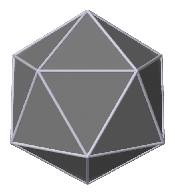

element =  Ag
number of vertices =  12
number of edges =  30
number of faces =  20
phi =  1.618033988749895
intershell factor = 1.05
nearest neighbour distance = 2.70 Å
intershell distance = 2.57 Å
edge length = 1.35 nm
radius after volume = 1.09 nm
radius of the circumscribed sphere = 1.28 nm
radius of the inscribed sphere = 1.02 nm
area = 15.8 nm2
volume = 5.4 nm3
number of atoms per shell =  [1, 12, 42, 92, 162, 252]
cumulative number of atoms per shell =  [1, 13, 55, 147, 309, 561]
total number of atoms =  561
Dual polyhedron: dodecahedron


Total number of atoms = 561
[1, 12, 42, 92, 162, 252]
Duration : 00:00:00 006ms


Moments of inertia = 3483379.35 3483379.35 3483379.35 amu.Å2
Moments of inertia / M = 57.56 57.56 57.56 amu.Å2
Moments of inertia with mass=1/M = 57.56 57.56 57.56 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Ih
Rotational Symmetry Number = 60
Duration : 00:00:00 226ms


Found:
  - 12 vertices
  - 20 simplices
Duration : 00:00:00 002ms


252 atoms lie in the plane(s)
Duration : 00:00:00 001ms


In [124]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the number of shells
nshells = 5
ico = pNP.regIco("Ag",
                 2.7,
                 nshells,
                 skipSymmetryAnalyzis=False,
                 noOutput=False
                )
pyNMBu.write("coords/ico.xyz", ico.NP)
pyNMBu.write("coords/ico_CoreSurface.xyz", ico.NPcs)
pyNMBu.write("coords/ico.script", ico.jMolCS)

### Extension: double icosahedron

**The double icosahedron cluster: ongoing work**

A specific structure that can be found in the litterature, for example :
- https://link.springer.com/article/10.1007/s100530170149 (more theory)
- https://pubs.acs.org/doi/pdf/10.1021/acs.nanolett.3c04435 (more experimental)

*Note: the dimension informations are accurate for the initial icosahedron only.*

Regular icosahedron with 3 shell(s) and Rnn = 2.7


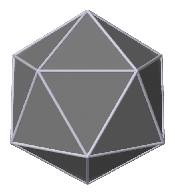

element =  Au
number of vertices =  12
number of edges =  30
number of faces =  20
phi =  1.618033988749895
intershell factor = 1.05
nearest neighbour distance = 2.70 Å
intershell distance = 2.57 Å
edge length = 0.81 nm
radius after volume = 0.65 nm
radius of the circumscribed sphere = 0.77 nm
radius of the inscribed sphere = 0.61 nm
area = 5.7 nm2
volume = 1.2 nm3
number of atoms per shell =  [1, 12, 42, 92]
cumulative number of atoms per shell =  [1, 13, 55, 147]
total number of atoms =  147
Dual polyhedron: dodecahedron


Nombre atomes avant troncature 147
Plane 1 used of truncation and reflection [ 0.         -0.52573111 -0.85065081  3.44513577]


22 atoms lie below the plane(s)
Nombre atomes après 1ere troncature 125
Total number of atoms = 250
[1, 12, 42, 92]
Duration : 00:00:00 012ms


Moments of inertia = 1253957.69 1953812.48 1953812.48 amu.Å2
Moments of inertia / M = 25.47 39.68 39.68 amu.Å2
Moments of inertia with mass=1/M = 25.47 39.68 39.68 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: C1
Rotational Symmetry Number = 1
Duration : 00:00:09 550ms


Found:
  - 17 vertices
  - 30 simplices
Duration : 00:00:00 001ms


152 atoms lie in the plane(s)
Duration : 00:00:00 002ms


In [132]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the number of shells
dico = pNP.regIco("Au",
                 2.7 ,
                 3,
                 double_ico = True,
                 skipSymmetryAnalyzis=False,
                 noOutput=False
                )
pyNMBu.write("coords/dico.xyz", dico.NP)
pyNMBu.write("coords/dico_CoreSurface.xyz", dico.NPcs) # algorithm struggling when concave ... still good to visualize the surface planes 
pyNMBu.write(f"coords/dico.script", dico.jMolCS)

### Regular fcc tetrahedra

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Tetrahedron)
</div>

In [ ]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.regfccTd?

Regular tetrahedron with 7 layer(s) and Rnn = 2.7


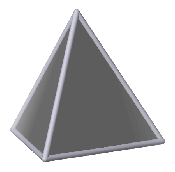

element =  Au
number of vertices =  4
number of edges =  6
number of faces =  4
nearest neighbour distance = 2.70 Å
edge length = 1.62 nm
number of atoms per edge = 7
inter-layer distance = 2.20 Å
height of pyramid = 1.32 nm
radius after volume = 0.49 nm
radius of the circumscribed sphere = 0.99 nm
radius of the inscribed sphere = 0.33 nm
radius of the midsphere tangent to edges = 0.57 nm
area = 4.5 nm2
volume = 0.5 nm3
face-vertex-edge angle = 54.7°
face-edge-face (dihedral) angle = 70.5°
vertex-center-vertex (tetrahedral bond) angle = 109.5°
number of atoms per layer =  [1, 3, 6, 10, 15, 21, 28]
Dual polyhedron: tetrahedron
Indexes of vertex atoms = [0,1,2,3] by construction
coordinates of the center of gravity = [0. 0. 0.]


Total number of atoms = 84
[]
Duration : 00:00:00 001ms


Moments of inertia = 361843.34 361843.34 361843.34 amu.Å2
Moments of inertia / M = 21.87 21.87 21.87 amu.Å2
Moments of inertia with mass=1/M = 21.87 21.87 21.87 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Td
Rotational Symmetry Number = 12
Duration : 00:00:00 027ms


Found:
  - 4 vertices
  - 4 simplices
Duration : 00:00:00 001ms


74 atoms lie in the plane(s)
Duration : 00:00:00 001ms


In [133]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a regular gold tetrahedron of 7 layers 
Td = pNP.regfccTd("Au",
                  2.7,
                  7,
                  noOutput=False)

# Save the XYZ/CIF files
pyNMBu.write("coords/Td.xyz", Td.NP)
pyNMBu.write("coords/Td_CoreSurface.xyz", Td.NPcs)
pyNMBu.write(f"coords/Td.script", Td.jMolCS)

### Extension: the Boerdijk-Coxeter helix

**Helix of tetrahedrons: the Boerdijk-Coxeter helix**

Again, it is a specific structure, if you want to learn more about it, go to the */Docs/helices/* folder. 

The new parameter is simply :             
- n_tetrahedrons (int): The  number of tetrahedrons in the optionnal helix.
  
*Notes: the dimensions are for one tetrahedron only, and the total number of atoms given by JMOL is also false (because atoms from the reflected plane are counted twice).
Please refer to "Helix Informations". 
Developements ongoing.*

Regular tetrahedron with 5 layer(s) and Rnn = 2.7


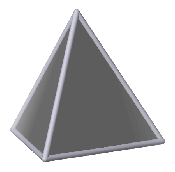

element =  Au
number of vertices =  4
number of edges =  6
number of faces =  4
nearest neighbour distance = 2.70 Å
edge length = 1.08 nm
number of atoms per edge = 5
inter-layer distance = 2.20 Å
height of pyramid = 0.88 nm
radius after volume = 0.33 nm
radius of the circumscribed sphere = 0.66 nm
radius of the inscribed sphere = 0.22 nm
radius of the midsphere tangent to edges = 0.38 nm
area = 2.0 nm2
volume = 0.1 nm3
face-vertex-edge angle = 54.7°
face-edge-face (dihedral) angle = 70.5°
vertex-center-vertex (tetrahedral bond) angle = 109.5°
number of atoms per layer =  [1, 3, 6, 10, 15]
Dual polyhedron: tetrahedron
Indexes of vertex atoms = [0,1,2,3] by construction
coordinates of the center of gravity = [0. 0. 0.]


Total number of atoms = 35
[]
Duration : 00:00:00 007ms


Moments of inertia = 1928380.48 55231738.10 55251156.12 amu.Å2
Moments of inertia / M = 13.99 400.59 400.73 amu.Å2
Moments of inertia with mass=1/M = 13.99 400.59 400.73 Å2


Found:
  - 23 vertices
  - 42 simplices
Duration : 00:00:00 002ms


218 atoms lie in the plane(s)
Duration : 00:00:00 004ms

Helix Information:
  Number of tetrahedrons in helix: 20
  Atoms per single tetrahedron: 35
  Total atoms in helix: 415



In [137]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make an helix of 20 tetrahedron of 5 layers each
bch = pNP.regfccTd("Au",
                  2.7,
                  nLayer = 5, 
                  n_tetrahedrons = 20,
                  postAnalyzis= True,
                  skipSymmetryAnalyzis= True,
                  noOutput=False,
                 )

# Save the XYZ/CIF files
pyNMBu.write("coords/bch.xyz", bch.NP)
pyNMBu.write("coords/bch_CoreSurface.xyz", bch.NPcs)
pyNMBu.write(f"coords/bch.script", bch.jMolCS)

### Regular dodecahedra

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Dodecahedron)
</div>

In [ ]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.regDD?

Regular dodecahedron with 5 shell(s) and Rnn = 2.7


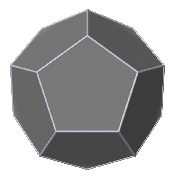

element =  Au
number of vertices =  20
number of edges =  30
number of faces =  12
phi =  1.618033988749895
intershell factor = 0.71
nearest neighbour distance = 2.70 Å
intershell distance = 3.78 Å
edge length = 1.35 nm
radius after volume = 0.69 nm
radius of the circumscribed sphere = 1.89 nm
radius of the inscribed sphere = 1.50 nm
area = 37.6 nm2
volume = 1.4 nm3
number of atoms per shell =  [1, 32, 122, 272, 482, 752]
total number of atoms =  1661
Dual polyhedron: icosahedron


Total number of atoms = 1661
[1, 32, 62, 92, 122, 152]
Duration : 00:00:00 013ms


Moments of inertia = 43141644.62 43141644.62 43141644.62 amu.Å2
Moments of inertia / M = 131.87 131.87 131.87 amu.Å2
Moments of inertia with mass=1/M = 131.87 131.87 131.87 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Ih
Rotational Symmetry Number = 60
Duration : 00:00:01 786ms


Found:
  - 20 vertices
  - 36 simplices
Duration : 00:00:00 002ms


752 atoms lie in the plane(s)
Duration : 00:00:00 002ms


In [138]:
from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu

# Define the number of shells:
nshells = 5
rdd = pNP.regDD("Au",
                2.7,
                nShell = nshells,
                noOutput=False)

# Save the XYZ/CIF files and the JMOL script
pyNMBu.write("coords/rdd.xyz", rdd.NP)
pyNMBu.write("coords/rdd_CoreSurface.xyz", rdd.NPcs)
pyNMBu.write(f"coords/rdd.script", rdd.jMolCS)

### Regular fcc octahedra

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Octahedron)
</div>

In [ ]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.regfccOh?

Regular octahedron of order 5 (i.e. 6 atoms lie on an edge) and Rnn = 2.7


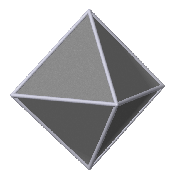

element =  Au
number of vertices =  6
number of edges =  12
number of faces =  8
intershell factor = 1.41
nearest neighbour distance = 2.70 Å
interlayer distance = 1.91 Å
edge length = 1.35 nm
number of atoms per edge = 6
radius after volume = 0.65 nm
radius of the circumscribed sphere = 0.95 nm
radius of the inscribed sphere = 0.55 nm
area = 3.2 nm2
volume = 1.2 nm3
dihedral angle = 109.5°
intermediate magic numbers =  [6, 19, 44, 85, 146]
total number of atoms =  146
Dual polyhedron: cube
Indexes of vertex atoms = [0,1,2,3,4,5] by construction
coordinates of the center of gravity = [0. 0. 0.]


Total number of atoms = 146
Duration : 00:00:00 002ms


Moments of inertia = 743789.10 743789.10 743789.10 amu.Å2
Moments of inertia / M = 25.86 25.86 25.86 amu.Å2
Moments of inertia with mass=1/M = 25.86 25.86 25.86 Å2


Found:
  - 6 vertices
  - 8 simplices
Duration : 00:00:00 001ms


102 atoms lie in the plane(s)
Duration : 00:00:00 001ms

SasView dimensions (for comparaison purposes when comparing to SasView models):
  t = 1, t being the truncature that is defined by the ratio d(truncated_demi_axis)/d(demi_axis)
  a = 9.545941546018392 Angs, a being the demi_axis being the distance from the center of the octahedron to a vertice (in Å)): (np.float64(9.545941546018392), 1)



In [139]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Define nOrder (the number of atomic layers along an edge)
fccOh = pNP.regfccOh("Au",
                     2.7,
                     5,
                     noOutput=False,
                     skipSymmetryAnalyzis=True
                    )

# Save the XYZ/CIF files
pyNMBu.write("coords/fccOh.xyz",fccOh.NP)
pyNMBu.write("coords/fccOh_CoreSurface.xyz",fccOh.NPcs)
pyNMBu.write("coords/fccOh.script",fccOh.jMolCS)

### Cubes

<div class="intro">

- [Wikipedia]()
- [Wolfram mathworld](https://mathworld.wolfram.com/Cube.html)
</div>

####  fcc cubes

In [ ]:
# If you need to look at the documentation
# from pyNanoMatBuilder import platonicNPs as pNP
# pNP.cube?

2x2x2 fcc cube with Rnn = 2.7


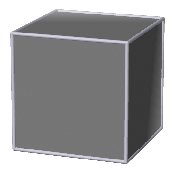

element =  Au
number of vertices =  8
number of edges =  12
number of faces =  6
nearest neighbour distance = 2.70 Å
lattice constant = 3.82 Å
edge length = 0.76 nm
radius after volume = 0.47 nm
radius of the circumscribed sphere = 0.66 nm
radius of the inscribed sphere = 0.38 nm
area = 3.5 nm2
volume = 0.4 nm3
total number of atoms =  63
Dual polyhedron: octahedron


Now making a 2x2x2 fcc supercell...
... and adding the upper layers
Duration : 00:00:00 003ms


Moments of inertia = 183793.44 183793.44 183793.44 amu.Å2
Moments of inertia / M = 14.81 14.81 14.81 amu.Å2
Moments of inertia with mass=1/M = 14.81 14.81 14.81 Å2


Found:
  - 8 vertices
  - 12 simplices
Duration : 00:00:00 002ms


50 atoms lie in the plane(s)
Duration : 00:00:00 002ms


In [141]:
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu

# Define nOrder (the number of atomic layers along an edge)
fcc = pNP.cube('fcc',
               'Au',
               Rnn= 2.7,
               nOrder = 2,
               noOutput=False,
               skipSymmetryAnalyzis = True,
               postAnalyzis= True
              ) 

# Save the XYZ/CIF files
pyNMBu.write("coords/fcccube.xyz", fcc.NP)
pyNMBu.write("coords/fcccube_CoreSurface.xyz", fcc.NP)
pyNMBu.write("coords/fcccube.script", fcc.jMolCS)

#### bcc cubes

7x7x7 bcc cube with Rnn = 2.47


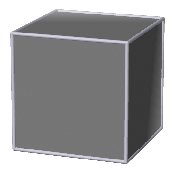

element =  Fe
number of vertices =  8
number of edges =  12
number of faces =  6
nearest neighbour distance = 2.47 Å
lattice constant = 2.85 Å
edge length = 2.00 nm
radius after volume = 1.24 nm
radius of the circumscribed sphere = 1.73 nm
radius of the inscribed sphere = 1.00 nm
area = 23.9 nm2
volume = 8.0 nm3
total number of atoms =  855
Dual polyhedron: octahedron


Now making a 7x7x7 fcc supercell...
... and adding the upper layers
Duration : 00:00:00 006ms


Moments of inertia = 3688696.87 3688696.87 3688696.87 amu.Å2
Moments of inertia / M = 77.25 77.25 77.25 amu.Å2
Moments of inertia with mass=1/M = 77.25 77.25 77.25 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Oh
Rotational Symmetry Number = 24
Duration : 00:00:00 354ms


Found:
  - 8 vertices
  - 12 simplices
Duration : 00:00:00 002ms


296 atoms lie in the plane(s)
Duration : 00:00:00 002ms


In [142]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Create a bcc cube of nOrder = 7
bcc = pNP.cube('bcc',
               'Fe',
               Rnn= 2.47,
               nOrder = 7,
               noOutput=False,
               skipSymmetryAnalyzis = False
              )

# Save the XYZ file
pyNMBu.write("coords/bcccube.xyz", bcc.NP)
pyNMBu.write("coords/bcccube_CoreSurface.xyz", bcc.NP)
pyNMBu.write("coords/bcccube.script", bcc.jMolCS)

### Extension: hollow cubes

<div class='intro'>
    
To create the hollow cube, first create a regular cube using the **cube** class, then create the hollow using the `hollow_shapes()` fu nction with the following parameters:
- **full_cube:** instance of the cube class
- **nOrder_hollow:** nOrder of the hollow

*Note: nOrder of the hollow must be inferior to the nOrder of the cube.*
</div>

In [143]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Create the full cube
full_cube=pNP.cube('fcc',
                   'Au',
                   Rnn=2.7,
                   nOrder=9,
                   noOutput=True,
                   skipSymmetryAnalyzis = True)

# Create its hollow counterpart
hollow_cube= pNP.hollow_shapes(full_cube = full_cube,
                               nOrder_hollow = 7,
                               noOutput=False,
                               skipSymmetryAnalyzis = True) 

# Save the files
pyNMBu.write("coords/fcccube.xyz", full_cube.NP)
pyNMBu.write("coords/fcchollowcube.xyz", hollow_cube.NP)
pyNMBu.write("coords/hollowcube.script", hollow_cube.jMolCS)

Number of atoms on an edge = 10
Edge length = 3.437 nm
Creating a hollow of nOrder = 7.
Number of atoms in the cube before creating the hollow = 3430


1688 atoms lie below the plane(s)
Number of atoms in the final hollow cube : 1742


Moments of inertia = 102525152.74 102525152.74 102525152.74 amu.Å2
Moments of inertia / M = 298.81 298.81 298.81 amu.Å2
Moments of inertia with mass=1/M = 298.81 298.81 298.81 Å2
[298.8063031 298.8063031 298.8063031]


Found:
  - 8 vertices
  - 12 simplices
Duration : 00:00:00 003ms


974 atoms lie in the plane(s)
Duration : 00:00:00 002ms


## Archimedean solids

This class uses the `platonicNPs` module to generate the parent structures, then applies a truncation of ~33% (chosen to approximate more stable shapes).  
As a result, the size parameters follow the same definitions as in the Platonic classes.

**Size parameters (same convention as Platonic NPs)**

| Parameter | Shape(s) | Meaning |
|---|---|---|
| **nOrder** | Truncated octahedron, truncated cube | Number of nested shells in a Russian-doll configuration (imbrication level) |
| **nShell** | Cuboctahedron | Number of concentric shells built outward from the center |
| **nLayer** | Truncated tetrahedron | Number of atomic layers, equivalently the number of atoms along an edge |



In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import archimedeanNPs as aNP

### Cuboctahedron

<div class="intro">

- [Wikipedia](https://en.wikipedia.org/wiki/Cuboctahedron)
- [Wolfram mathworld](https://mathworld.wolfram.com/Cuboctahedron.html)
</div>


In [ ]:
# # If you want to read the documentation
# from pyNanoMatBuilder import archimedeanNPs as aNP
# aNP.fccCubo?

Cuboctahedron with 5 shell(s) and Rnn = 2.7


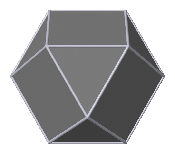

element =  Au
number of vertices =  12
number of edges =  24
number of faces =  14
intershell factor = 1.00
nearest neighbour distance = 2.70 Å
intershell distance = 2.70 Å
edge length = 1.35 nm
radius after volume = 1.11 nm
radius of the circumscribed sphere = 1.35 nm
radius of the inscribed sphere = 1.01 nm
area = 17.2 nm2
volume = 5.8 nm3
number of atoms per shell =  [1, 12, 42, 92, 162, 252]
cumulative number of atoms per shell =  [1, 13, 55, 147, 309, 561]
total number of atoms =  561
Dual polyhedron: rhombic dodecahedron


Total number of atoms = 561
[1, 12, 42, 92, 162, 252]
Duration : 00:00:00 013ms


Moments of inertia = 6823331.64 6823331.64 6823331.64 amu.Å2
Moments of inertia / M = 61.75 61.75 61.75 amu.Å2
Moments of inertia with mass=1/M = 61.75 61.75 61.75 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Oh
Rotational Symmetry Number = 24
Duration : 00:00:00 229ms


Found:
  - 12 vertices
  - 20 simplices
Duration : 00:00:00 001ms


252 atoms lie in the plane(s)
Duration : 00:00:00 001ms


In [145]:
from pyNanoMatBuilder import archimedeanNPs as aNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a cuboctahedron of 5 shells (number of atomic layers along an edge)
cubo = aNP.fccCubo("Au",
                   2.7,
                   5,
                   noOutput=False,
                   postAnalyzis= True
                  )

# Save the XYZ files and the JMOL script
pyNMBu.write("coords/cubo.xyz", cubo.NP)
pyNMBu.write("coords/cubo_CoreSurface.xyz", cubo.NPcs)
pyNMBu.write("coords/cubo.script", cubo.jMolCS)

### Truncated fcc tetrahedron

<div class="intro">

- [Wikipedia](https://en.wikipedia.org/wiki/Truncated_tetrahedron)
- [Wolfram mathworld](https://mathworld.wolfram.com/TruncatedTetrahedron.html)
</div>

In [ ]:
# If you want to read the documenation
#from pyNanoMatBuilder import archimedeanNPs as aNP
# aNP.fccTrTd?

Truncated tetrahedron based on a 7 layer(s) Td and Rnn = 2.7


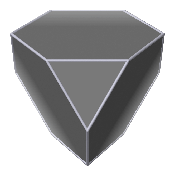

element =  Au
number of vertices =  12
number of edges =  18
number of triangular faces =  4
number of hexagonal faces =  4
truncation all 4 vertices of a regular tetrahedron at 0.333a_Td from the vertices of the Td
nearest neighbour distance = 2.70 Å
inter layer distance = 2.20 Å
edge length = 0.54 nm
number of atoms per edge = 3
area = 3.5 nm2
volume = 0.4 nm3
radius of the circumscribed sphere = 0.63 nm
total number of atoms =  68
dual polyhedron: triakis tetrahedron
coordinates of the center of gravity = [0. 0. 0.]


First searching for the coordinates of the vertices (atoms 1-4) and of the cog
Now calculating the coordinates of the planes orthogonal the the cog-vertex directions
factor = 0.333 ▶ 2 layer(s) will be removed, starting from each vertex
Will remove atoms just above plane -0.58 -0.58 0.58 d:-5.622


68 atoms lie below the plane(s)
Total number of atoms = 68
Duration : 00:00:00 009ms


Moments of inertia = 212511.17 212511.17 212511.17 amu.Å2
Moments of inertia / M = 15.87 15.87 15.87 amu.Å2
Moments of inertia with mass=1/M = 15.87 15.87 15.87 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Td
Rotational Symmetry Number = 3
Duration : 00:00:00 054ms


Found:
  - 12 vertices
  - 20 simplices
Duration : 00:00:00 002ms


58 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 1.27 nm
diameters of the inscribed sphere: 0.66 nm
(the inscribed sphere was not given before because it was not trivial to compute it based on the truncated tetrahedron geometry. The general method is now used)


In [146]:
from pyNanoMatBuilder import archimedeanNPs as aNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a truncated tetrahedron from an tetrahedron of 16 shells
trTd = aNP.fccTrTd("Au",
                   2.7,
                   7,
                   noOutput=False,
                   postAnalyzis= True
                  )

# Save the XYZ files and JMOL script
pyNMBu.write("coords/Td-2truncate.xyz", trTd.NP0) # the initial tetrahedron
pyNMBu.write("coords/trTd.xyz", trTd.NP) # the truncated one
pyNMBu.write("coords/trTd_CoreSurface.xyz", trTd.NPcs)
pyNMBu.write("coords/trTd.script", trTd.jMolCS)

### Truncated fcc octahedron

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import archimedeanNPs as aNP
# aNP.fccTrOh?

Truncated octahedron based on a 12 order Oh (i.e. 13 atoms lie on an edge) and Rnn = 2.7


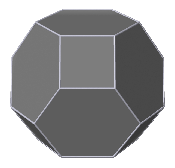

element =  Au
number of vertices =  24
number of edges =  36
number of square faces =  6
number of hexagonal faces =  8
truncation all 6 vertices of a regular octahedron at 0.333a_Oh from the vertices of the Oh
nearest neighbour distance = 2.70 Å
inter layer distance = 1.91 Å
edge length = 1.08 nm
radius of the circumscribed sphere = 1.71 nm
radius of the medium sphere = 1.62 nm
radius of the inscribed sphere = 1.54 nm
number of atoms per edge = 5
area = 31.2 nm2
volume = 14.3 nm3
total number of atoms =  1289
dual polyhedron: triakis hexahedron
coordinates of the center of gravity = [0. 0. 0.]


First searching for the coordinates of the vertices (atoms 1-6) and of the cog
Now calculating the coordinates of the planes orthogonal the the cog-vertex directions
factor = 0.333 ▶ 4 layer(s) will be removed, starting from each vertex
Will remove atoms just above plane 0.00 -0.00 1.00 d:-15.274
Total number of atoms = 1289
Duration : 00:00:00 013ms


Moments of inertia = 27121020.21 27121020.21 27121020.21 amu.Å2
Moments of inertia / M = 106.82 106.82 106.82 amu.Å2
Moments of inertia with mass=1/M = 106.82 106.82 106.82 Å2


Found:
  - 24 vertices
  - 44 simplices
Duration : 00:00:00 002ms


482 atoms lie in the plane(s)
Duration : 00:00:00 002ms

SasView dimensions (for comparaison purposes when comparing to SasView models):
  t = 0.667, t being the truncature that is defined by the ratio d(truncated_demi_axis)/d(demi_axis)
  a = 22.91 Angs, a being the demi_axis being the distance from the center of the octahedron to a vertice (in Å)): (np.float64(22.910259710444144), np.float64(0.6666666666666667))



In [149]:
# from pyNanoMatBuilder import archimedeanNPs as aNP
# from pyNanoMatBuilder import utils as pyNMBu

# Let's mahe a truncated octahedron from an octahedron of order = 12
trOh = aNP.fccTrOh("Au",
                   2.7,
                   12,
                   noOutput=False,
                   skipSymmetryAnalyzis=True
                  )

# Save the XYZ files
pyNMBu.write("coords/trOh_original.xyz", trOh.NP0) # the initial octahedron
pyNMBu.write("coords/trOh.xyz", trOh.NP) # the truncated one
pyNMBu.write("coords/trOh.script", trOh.jMolCS)

### Truncated fcc cube (in progress)

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Truncated_cube)

[Wolfram MathWorld](https://mathworld.wolfram.com/TruncatedCube.html)
</div>



In [ ]:
# if you want to read the documentation
# from pyNanoMatBuilder import archimedeanNPs as aNP
# aNP.fccTrCube?

In [150]:
from pyNanoMatBuilder import archimedeanNPs as aNP
from pyNanoMatBuilder import utils as pyNMBu

trCube = aNP.fccTrCube("Au",
                       2.7,
                       6,
                       noOutput=False,
                       calcPropOnly=False
                      )

pyNMBu.write("coords/Cube-2truncate.xyz", trCube.NP0)
pyNMBu.write("coords/trCube.xyz", trCube.NP)
pyNMBu.write("coords/trCube_CoreSurface.xyz", trCube.NPcs)
pyNMBu.write("coords/trCube.script", trCube.jMolCS)

Truncated cube based on a 6x6x6 cube (i.e. 7 atoms lie on an edge) and Rnn = 2.7
element =  Au
number of vertices =  24
number of edges =  36
number of trigonal faces =  8
number of octogonal faces =  6
truncation all 6 vertices of a regular octahedron at 0.333a_cube from the vertices of the cube
nearest neighbour distance = 2.70 Å
edge length = 0.76 nm
radius of the circumscribed sphere = 1.36 nm
radius of the medium sphere = 1.30 nm
radius of the inscribed sphere = 1.25 nm
number of atoms per edge = 3
area = 18.9 nm2
volume = 6.1 nm3
dual polyhedron: Triakis octahedron
coordinates of the center of gravity = [0. 0. 0.]


First searching for the coordinates of the vertices and of the cog
Vertices = coords  [[-11.45512986 -11.45512986 -11.45512986]
 [-11.45512986 -11.45512986  11.45512986]
 [-11.45512986  11.45512986 -11.45512986]
 [-11.45512986  11.45512986  11.45512986]
 [ 11.45512986 -11.45512986 -11.45512986]
 [ 11.45512986 -11.45512986  11.45512986]
 [ 11.45512986  11.45512986 -11.45512986]
 [ 11.45512986  11.45512986  11.45512986]]
Now calculating the coordinates of the planes orthogonal the the cog-vertex directions
factor = 0.333 ▶ 2 layer(s) will be removed, starting from each vertex
Will remove atoms just above plane 0.58 0.58 0.58 d:-13.227
Total number of atoms = 923
Duration : 00:00:00 013ms


Moments of inertia = 15679878.27 15679878.27 15679878.27 amu.Å2
Moments of inertia / M = 86.25 86.25 86.25 amu.Å2
Moments of inertia with mass=1/M = 86.25 86.25 86.25 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Oh
Rotational Symmetry Number = 24
Duration : 00:00:00 382ms


Found:
  - 12 vertices
  - 20 simplices
Duration : 00:00:00 002ms


362 atoms lie in the plane(s)
Duration : 00:00:00 002ms


## Catalan solids

<div class="intro">
    
**Size parameter**

The **bcc rhombic dodecahedron** and **fcc dihedral rhombic dodecahedron** are constructed using a size parameter that defines the extent of the structure:

| Parameter | Description |
|-----------|-------------|
| **nShell** |  Number of concentric shells built outward from the center  |

</div>


### Bcc rhombic dodecahedron (not working)


<div class="intro">

- [Wikipedia](https://en.wikipedia.org/wiki/Rhombic_dodecahedron)
- [Wolfram mathworld](https://mathworld.wolfram.com/RhombicDodecahedron.html)
</div>

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import catalanNPs as cNP
# cNP.bccrDD?

Bcc rhombic dodecahedron with 8 shell(s) and Rnn = 2.47


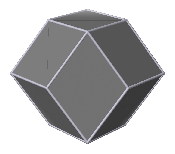

element =  Fe
number of vertices =  14
number of edges =  24
number of faces =  12
intershell factor 3 = 1.00
intershell factor 4 = 0.87
nearest neighbour distance = 2.47 Å
intershell distance for 3rd order vertices = 2.47 Å
intershell distance for 4th order vertices = 2.85 Å
edge length = 1.98 nm
radius after volume = 1.78 nm
radius of the circumscribed sphere passing through the six 4th order vertices = 2.28 nm
radius of the circumscribed sphere passing through the eight 3rd order vertices = 1.98 nm
radius of the midsphere = 1.86 nm
radius of the inscribed sphere = 1.61 nm
area = 44.2 nm2
volume = 23.8 nm3
number of atoms per shell =  [1, 14, 50, 110, 194, 302, 434, 590, 770]
cumulative number of atoms per shell =  [1, 15, 65, 175, 369, 671, 1105, 1695, 2465]
total number of atoms =  2465
Dual polyhedron: 
coordinates of the center of gravity = [0. 0. 0.]


Total number of atoms = 2537
[1, 14, 50, 110, 194, 302, 434, 626, 806]
Duration : 00:00:00 022ms


Moments of inertia = 21112647.65 21112647.65 21114819.37 amu.Å2
Moments of inertia / M = 149.02 149.02 149.03 amu.Å2
Moments of inertia with mass=1/M = 149.02 149.02 149.03 Å2


Found:
  - 14 vertices
  - 24 simplices
Duration : 00:00:00 002ms


806 atoms lie in the plane(s)
Duration : 00:00:00 001ms


diameters of the circumscribed sphere: 4.58 nm
diameters of the inscribed sphere: 3.23 nm


In [151]:
from pyNanoMatBuilder import catalanNPs as cNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a rhombic dodecahedron of 5 shells
bccrdd = cNP.bccrDD("Fe",
                    2.47,
                    8,
                    noOutput=False,
                    skipSymmetryAnalyzis= True
                   )

# Save the XYZ files and JMOL script
pyNMBu.write("coords/bccrdd.xyz", bccrdd.NP)
pyNMBu.write("coords/bccrdd_CoreSurface.xyz", bccrdd.NPcs)
pyNMBu.write("coords/bccrdd.script", bccrdd.jMolCS)

### Fcc dihedral rhombic dodecahedron

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import catalanNPs as cNP
# cNP.fccdrDD?

Dihedral rhombic dodecahedron (drDD) with 8 shell(s) and Rnn = 2.7


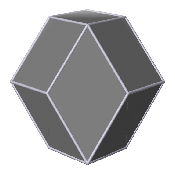

element =  Au
number of vertices =  14
number of edges =  32
number of faces =  12
intershell factor = 1.00
intershell factor for tob and bottom vertices = 0.71
nearest neighbour distance = 2.70 Å
intershell distance = 2.70 Å
intershell distance for top and bottom vertices = 3.82 Å
edge length = 2.16 nm
radius after volume = 1.95 nm
area = 52.8 nm2
volume = 31.0 nm3
number of atoms per shell =  [3, 16, 76, 184, 340, 544, 796, 1096, 1444]
cumulative number of atoms per shell =  [3, 19, 95, 279, 619, 1163, 1959, 3055, 4499]
total number of atoms =  4499
Dual polyhedron: 
Comment: It can be seen as a cuboctahedron with square pyramids augmented on the top and bottom
coordinates of the center of gravity = [0. 0. 0.]


Total number of atoms = 2465
[1, 14, 50, 110, 194, 302, 434, 590, 770]
Duration : 00:00:00 019ms


Moments of inertia = 63856735.00 95785102.50 95785102.50 amu.Å2
Moments of inertia / M = 131.52 197.28 197.28 amu.Å2
Moments of inertia with mass=1/M = 131.52 197.28 197.28 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: D4h
Rotational Symmetry Number = 8
Duration : 00:00:01 275ms


Found:
  - 14 vertices
  - 24 simplices
Duration : 00:00:00 002ms


770 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 6.11 nm
diameters of the inscribed sphere: 3.05 nm


In [155]:
from pyNanoMatBuilder import catalanNPs as cNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a dihedral rhombic dodecahedron of 5 shells
fccdrdd = cNP.fccdrDD("Au",
                      2.7,
                      8,
                      skipSymmetryAnalyzis = False,
                      noOutput=False
                      )

# Save the XYZ files and jmol script
pyNMBu.write("coords/fccdrdd.xyz", fccdrdd.NP)
pyNMBu.write("coords/fccdrdd_CoreSurface.xyz", fccdrdd.NPcs)
pyNMBu.write("coords/fccdrdd.script", fccdrdd.jMolCS)

## Johnson solids

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Johnson_solid)

[Wolfram MathWorld](https://mathworld.wolfram.com/JohnsonSolid.html)
</div>

<div class="intro">

This class defines **two shape families**:

**1. fcc trigonal bipyramid**

Size parameter:

| Parameter | Meaning |
|---|---|
| **nLayerTd** | Number of atomic layers in **one** tetrahedral pyramid. The full bipyramid has **2 × nLayerTd** layers (top + bottom). |

---

**2. pentagonal bipyramids, including elongated and truncated variants**

Size parameters:

| Parameter | Meaning |
|---|---|
| **sizeP** | Number of layers in the pentagonal cross-section (equivalently, number of bonds per pentagonal edge). |
| **sizeE** | Number of layers along the elongated height direction (number of bonds per elongated edge). |
| **Marks** | Truncation depth per pentagonal edge, expressed as number of atoms removed. The total truncation at a full vertex is **2 × Marks**. |

</div>

### Fcc trigonal bipyramid

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import johnsonNPs as jNP
# jNP.fcctbp?

Regular fcc double tetrahedron of Au with 34 layer(s) and Rnn = 2.7


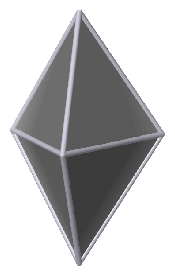

element =  Au
number of vertices =  5
number of edges =  9
number of faces =  6
nearest neighbour distance = 2.70 Å
edge length = 4.59 nm
inter-layer distance = 2.20 Å
number of atoms per edge = 18
height of bipyramid = 7.50 nm
area = 48.5 nm2
volume = 19.0 nm3
face-vertex-edge angle = 54.7°
face-edge-face (dihedral) angle = 70.5°
vertex-center-vertex (tetrahedral bond) angle = 109.5°
Dual polyhedron: triangular prism
Indexes of vertex atoms = [0,1,2,3] by construction
coordinates of the center of gravity = [0. 0. 0.]


hkl solution: -1.00000 x + -1.00000 y + 1.00000 z + 16.22810 = 0
Total number of atoms = 2280
Duration : 00:00:00 065ms


Moments of inertia = 58437700.15 97859958.19 97859958.19 amu.Å2
Moments of inertia / M = 130.13 217.91 217.91 amu.Å2
Moments of inertia with mass=1/M = 130.13 217.91 217.91 Å2


Found:
  - 5 vertices
  - 6 simplices
Duration : 00:00:00 002ms


920 atoms lie in the plane(s)
Duration : 00:00:00 001ms


diameters of the circumscribed sphere: 7.50 nm
diameters of the inscribed sphere: 2.50 nm


In [156]:
from pyNanoMatBuilder import johnsonNPs as jNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a trigonal bipyramid from singular pyramids of 6 layers each  (= 12 layers in the bipyramid)
tbp = jNP.fcctbp("Au",
                 2.7,
                 17,
                 noOutput=False,
                 skipSymmetryAnalyzis = True
                )

# Save the XYZ files and jmol script
pyNMBu.write("coords/Td-5tpb.xyz", tbp.NP0) # one pyramid
pyNMBu.write("coords/tbp.xyz", tbp.NP) # the bipyramid
pyNMBu.write("coords/tbp_CoreSurface.xyz", tbp.NPcs)
pyNMBu.write("coords/tbp.script", tbp.jMolCS)

### Pentagonal bipyramids (decahedron) and elongated bipyramids

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import johnsonNPs as jNP
# jNP.epbpyM?

#### Decahedron

Pentagonal pyramid with 6 atoms per edge on the pentagonal cap, 0 layer(s) in the elongated part, no Marks truncation and Rnn = 2.7


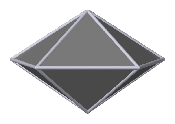

element =  Au
number of vertices =  7
number of edges =  15
number of faces =  10
magic factor = 1.051 (ratio between the height of the vertical interatomic distance and the nearest-neighbour distance)
nearest neighbour distance = 2.70 Å
edge length of the pentagonal cap = 1.35 nm
edge length of the elongated part = 0.00 nm
inter compact planes factor = 0.809
inter compact planes distance = 2.18 Å
number of atoms per edge on the pentagonal cap = 6
heightOfPyramidF =  0.5257311121191336
natomsPerEdgeOfPC =  6
height of the bipyramid = 14.19 Å
area = 7.9 nm2
volume = 1.5 nm3
Dual polyhedron: triangular prism
coordinates of the center of gravity = [0. 0. 0.]


Total number of atoms = 181
Duration : 00:00:00 003ms


Moments of inertia = 1012691.86 1012691.86 1525328.52 amu.Å2
Moments of inertia / M = 28.41 28.41 42.79 amu.Å2
Moments of inertia with mass=1/M = 28.41 28.41 42.79 Å2


Found:
  - 7 vertices
  - 10 simplices
Duration : 00:00:00 001ms


127 atoms lie in the plane(s)
Duration : 00:00:00 001ms


diameters of the circumscribed sphere: 2.30 nm
diameters of the inscribed sphere: 1.13 nm


In [158]:
from pyNanoMatBuilder import johnsonNPs as jNP
from pyNanoMatBuilder import utils as pyNMBu

########################################################################################
# 1. Make a regular dodecahedron of 5 shells per edges
########################################################################################
sizeOfThePentagone = 5
sizeOfTheElongatedPart = 0
MarksTruncation = 0

ppy1 = jNP.epbpyM("Au",
                  2.7,
                  sizeP = sizeOfThePentagone,
                  sizeE = sizeOfTheElongatedPart,
                  Marks = MarksTruncation,
                  skipSymmetryAnalyzis= True,
                  thresholdCoreSurface=1,
                  noOutput=False
                 )

pyNMBu.write("coords/ppy1.xyz", ppy1.NP)
pyNMBu.write("coords/ppy1_CoreSurface.xyz", ppy1.NPcs)
pyNMBu.write("coords/ppy1.script", ppy1.jMolCS)


#### Ino decahedron

Pentagonal pyramid with 6 atoms per edge on the pentagonal cap, 8 layer(s) in the elongated part, no Marks truncation and Rnn = 2.7


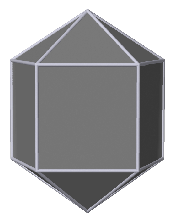

element =  Au
number of vertices =  12
number of edges =  20
number of faces =  15
magic factor = 1.051 (ratio between the height of the vertical interatomic distance and the nearest-neighbour distance)
nearest neighbour distance = 2.70 Å
edge length of the pentagonal cap = 1.35 nm
edge length of the elongated part = 2.27 nm
inter compact planes factor = 0.809
inter compact planes distance = 2.18 Å
number of atoms per edge on the pentagonal cap = 6
heightOfPyramidF =  0.5257311121191336
natomsPerEdgeOfPC =  6
height of the elongated bipyramid = 3.69 nm
Dual polyhedron: pentagonal bifrustum
coordinates of the center of gravity = [0. 0. 0.]


Total number of atoms = 820
Duration : 00:00:00 014ms


Moments of inertia = 9017367.34 16673030.00 16673030.00 amu.Å2
Moments of inertia / M = 55.83 103.23 103.23 amu.Å2
Moments of inertia with mass=1/M = 55.83 103.23 103.23 Å2


Found:
  - 12 vertices
  - 20 simplices
Duration : 00:00:00 002ms


327 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 3.69 nm
diameters of the inscribed sphere: 1.86 nm


In [159]:
########################################################################################
# 2. Make a dodecahedron of 5 shells with an elongation of 8 shells along its height
########################################################################################
sizeOfThePentagone = 5
sizeOfTheElongatedPart = 8
MarksTruncation = 0

ppy2 = jNP.epbpyM("Au",
                  2.7,
                  sizeP = sizeOfThePentagone,
                  sizeE = sizeOfTheElongatedPart,
                  Marks = MarksTruncation,
                  skipSymmetryAnalyzis= True,
                  thresholdCoreSurface=1,
                  noOutput=False
                 )

pyNMBu.write("coords/ppy2.xyz", ppy2.NP)
pyNMBu.write("coords/ppy2_CoreSurface.xyz", ppy2.NPcs)
pyNMBu.write("coords/ppy3.script", ppy2.jMolCS)

#### Marks decahedron

Pentagonal pyramid with 11 atoms per edge on the pentagonal cap, 0 layer(s) in the elongated part, a Marks truncation by 3 atom(s) and Rnn = 2.7


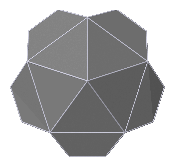

element =  Au
magic factor = 1.051 (ratio between the height of the vertical interatomic distance and the nearest-neighbour distance)
nearest neighbour distance = 2.70 Å

Dimensions before Marks truncation:
edge length of the pentagonal cap = 2.70 nm
edge length of the elongated part = 0.00 nm
inter compact planes factor = 0.809
inter compact planes distance = 2.18 Å
number of atoms per edge on the pentagonal cap = 11

Dimensions after truncation by 3 atom(s) at the vertices:
number of atoms per edge of the pentagonal cap after truncation = 5
edge length of the pentagonal cap after truncation = 1.08 nm
edge length of the elongated part after truncation = 0.00 nm
heightOfPyramidF =  0.5257311121191336
natomsPerEdgeOfPC =  11
height of the Marks decahedron = 28.39 Å
coordinates of the center of gravity = [0. 0. 0.]


267 atoms lie below the plane(s)


258 atoms lie below the plane(s)


249 atoms lie below the plane(s)


240 atoms lie below the plane(s)


231 atoms lie below the plane(s)
Total number of atoms = 1042
Duration : 00:00:00 016ms


Moments of inertia = 18511708.14 18511708.14 26488342.72 amu.Å2
Moments of inertia / M = 90.20 90.20 129.06 amu.Å2
Moments of inertia with mass=1/M = 90.20 90.20 129.06 Å2


Found:
  - 22 vertices
  - 40 simplices
Duration : 00:00:00 002ms


437 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 3.87 nm
diameters of the inscribed sphere: 2.26 nm


In [160]:
########################################################################################
# 3. Make a dodecahedron of 10 shells with a Marks truncation of 3 atoms per edge (= 6 atoms per vertices)
########################################################################################
sizeOfThePentagone = 10
sizeOfTheElongatedPart = 0
MarksTruncation = 3

ppy3 = jNP.epbpyM("Au",
                  2.7,
                  sizeP = sizeOfThePentagone,
                  sizeE = sizeOfTheElongatedPart,
                  Marks = MarksTruncation,
                  skipSymmetryAnalyzis= True,
                  noOutput=False
                 )

pyNMBu.write("coords/ppy3.xyz", ppy3.NP)
pyNMBu.write("coords/ppy3_CoreSurface.xyz", ppy3.NPcs)
pyNMBu.write("coords/ppy3.script", ppy3.jMolCS)

#### "Elongated" Marks decahedron

Pentagonal pyramid with 11 atoms per edge on the pentagonal cap, 5 layer(s) in the elongated part, a Marks truncation by 3 atom(s) and Rnn = 2.7


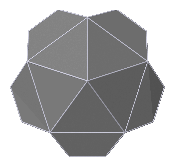

element =  Au
magic factor = 1.051 (ratio between the height of the vertical interatomic distance and the nearest-neighbour distance)
nearest neighbour distance = 2.70 Å

Dimensions before Marks truncation:
edge length of the pentagonal cap = 2.70 nm
edge length of the elongated part = 1.42 nm
inter compact planes factor = 0.809
inter compact planes distance = 2.18 Å
number of atoms per edge on the pentagonal cap = 11

Dimensions after truncation by 3 atom(s) at the vertices:
number of atoms per edge of the pentagonal cap after truncation = 5
edge length of the pentagonal cap after truncation = 1.08 nm
edge length of the elongated part after truncation = 1.42 nm
heightOfPyramidF =  0.5257311121191336
natomsPerEdgeOfPC =  11
height of the elongated Marks decahedron = 4.26 nm
coordinates of the center of gravity = [0. 0. 0.]


267 atoms lie below the plane(s)


258 atoms lie below the plane(s)


249 atoms lie below the plane(s)


240 atoms lie below the plane(s)


231 atoms lie below the plane(s)
Total number of atoms = 2272
Duration : 00:00:00 046ms


Moments of inertia = 67348485.53 67348485.53 69619573.41 amu.Å2
Moments of inertia / M = 150.50 150.50 155.57 amu.Å2
Moments of inertia with mass=1/M = 150.50 150.50 155.57 Å2


Found:
  - 32 vertices
  - 60 simplices
Duration : 00:00:00 003ms


612 atoms lie in the plane(s)
Duration : 00:00:00 005ms


diameters of the circumscribed sphere: 4.26 nm
diameters of the inscribed sphere: 3.38 nm


In [161]:
########################################################################################
# 4. Combine 2. and 3. : Make dodecahedron of 10 shells with a elongation of 5 shells
# and a Marks truncation of 3 atoms per edge (= 6 atoms per vertices)
########################################################################################
sizeOfThePentagone = 10
sizeOfTheElongatedPart = 5
MarksTruncation = 3

ppy4 = jNP.epbpyM("Au",
                  2.7,
                  sizeP =sizeOfThePentagone,
                  sizeE = sizeOfTheElongatedPart,
                  Marks = MarksTruncation,
                  skipSymmetryAnalyzis= True,
                  noOutput=False
                 )

pyNMBu.write("coords/ppy4.xyz", ppy4.NP)
pyNMBu.write("coords/ppy4_CoreSurface.xyz", ppy4.NPcs)
pyNMBu.write("coords/ppy4.script", ppy4.jMolCS)

## Other solids

For now, only the platelet exists. It is built by adding two truncated tetrahedrons to create a bipyramid, then potentially adding shells between the two pyramids.

Size parameter:

| Parameter | Meaning |
|---|---|
| **nLayerTd** | Number of layers (bonds per edge) of the two tetrahedrons used to create the platelet. This value will define the edge length of the final platelet; the number of layers of the platelet will be `nLayerTd + 1`. |
| **nLayer** | The number of layers kept for each tetrahedron (not counting the twin plane). This value will define the thickness of the platelet; the number of layers in the final platelet will be `nLayer * 2`. |


In [ ]:
from pyNanoMatBuilder import otherNPs as oNP

### Platelets

#### Triangular fcc platelets 

In [ ]:
# If you want to read the documentation
# from pyNanoMatBuilder import otherNPs as oNP
#  oNP.fcctpt?

Truncated fcc double tetrahedron with 7 layer(s) and Rnn = 2.47


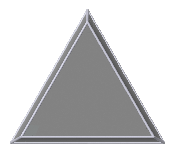

element =  Fe
number of vertices =  9
number of edges =  9
number of faces =  8
nearest neighbour distance = 2.47 Å
edge length of the tetrahedrons used to create the double truncated tetrahedron = 3.71 nm
longest edge length of the platelet (at twin boundary) = 3.95 nm
number of atoms per edge at the twin boundary = 17
inter-layer distance = 2.02 Å
height of the platelet = 1.21 nm
face-vertex-edge angle in Td = 54.7°
face-edge-face (dihedral) angle in Td = 70.5°
vertex-center-vertex (tetrahedral bond) angle in Td = 109.5°
coordinates of the center of gravity = [0. 0. 0.]


Now calculating the coordinates of the twin plane (defined by atoms 0, 1, 2)
bare solution: -0.57735 x + -0.57735 y + 0.57735 z + -0.00000 = 0
hkl solution: -1.00000 x + -1.00000 y + 1.00000 z + -0.00000 = 0
Now calculating the coordinates of the truncation planes
signed distance between truncation plane 1 and origin = -6.05
signed distance between truncation plane 2 and origin = -6.05
Duration : 00:00:00 026ms
Total number of atoms = 1028


Moments of inertia = 4503208.39 4503208.39 7588176.43 amu.Å2
Moments of inertia / M = 78.44 78.44 132.18 amu.Å2
Moments of inertia with mass=1/M = 78.44 78.44 132.18 Å2


Found:
  - 9 vertices
  - 14 simplices
Duration : 00:00:00 001ms


480 atoms lie in the plane(s)
Duration : 00:00:00 001ms


diameters of the circumscribed sphere: 4.56 nm
diameters of the inscribed sphere: 1.21 nm


Found:
  - 9 convex Hull vertices
  - 14 convex Hull simplices before reduction
  - 8 facets after reduction
New trPlanes saved in self.trPlanes


Jmol command:  draw line0 [{11.0615,11.0615,11.6437},{-11.6437,11.0615,-11.0615},] width 0.2; draw line1 [{-11.6437,11.0615,-11.0615},{11.0615,-11.6437,-11.0615},] width 0.2; draw line2 [{11.0615,-11.6437,-11.0615},{11.0615,11.0615,11.6437},] width 0.2; draw line3 [{4.0753,-18.6299,-4.0753},{4.0753,4.0753,18.6299},] width 0.2; draw line4 [{4.0753,4.0753,18.6299},{-18.6299,4.0753,-4.0753},] width 0.2; draw line5 [{-18.6299,4.0753,-4.0753},{4.0753,-18.6299,-4.0753},] width 0.2; draw line6 [{-18.6299,9.3150,-9.3150},{-18.6299,4.0753,-4.0753},] width 0.2; draw line7 [{-18.6299,4.0753,-4.0753},{4.0753,-18.6299,-4.0753},] width 0.2; draw line8 [{4.0753,-18.6299,-4.0753},{9.3150,-18.6299,-9.3150},] width 0.2; draw line9 [{9.3150,-18.6299,-9.3150},{-18.6299,9.3150,-9.3150},] width 0.2; draw line10 [{-18.6299,9.3150,-9.3150},{9.3150,-18.6299,-9.3150},] width 0.2; draw line11 [{9.3150,-18.6299,-9.3150},{11.0615,-11.6437,-11.0615},] width 0.2; draw line12 [{11.0615,-11.6437,-11.0615},{-11.6437,11

In [163]:
from pyNanoMatBuilder import otherNPs as oNP
import pyNanoMatBuilder.utils as pyNMBu

# Let's make the double truncated tetrahedron with: 
lengthEdge = 15 # LENGTH OF THE PLATELET : 15 layers (bonds per edge) for each tetrahedrons, the final edge will have 16 layers (bonds per edge)
nshells = 3 # HEIGHT OF THE PLATELET : 3 shells kept for each tetrahedrons, the final number of shells will be 6 
tpt = oNP.fcctpt("Fe",
                 2.47,
                 lengthEdge,
                 nshells,
                 noOutput=False,
                 skipSymmetryAnalyzis=True,
                )

# Save the XYZ files and JMOL script
pyNMBu.write("coords/tbp_4tpt.xyz", tpt.NP0)
pyNMBu.write("coords/tpt.xyz", tpt.NP)
pyNMBu.write("coords/tpt_CoreSurface.xyz", tpt.NPcs)
pyNMBu.write("coords/tpt.script", tpt.jMolCS)


# Geometry optimization with ase

https://ase-lib.org/ase/calculators/emt.html

*Note: Supports the following standard EMT metals: Al, Cu, Ag, Au, Ni, Pd and Pt.*

In [ ]:
pyNMBu.optimizeEMT?

## Regular fcc octahedra

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

# Create your NP structure
fccOh = pNP.regfccOh("Au", 2.7, 5)
aseOh = fccOh.NP
view(aseOh)

# Do the optimization
aseOhOpt = pyNMBu.optimizeEMT(aseOh,'./coords/fccOh')
view(aseOhOpt)

# Get some supplementary infos of the optimized structure
pyNMBu.moi(aseOhOpt)
pyNMBu.MolSym(aseOhOpt)

## Regular dodecahedra

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

# Create your NP structure
rdd = pNP.regDD("Au",2.7,4)
aserdd = rdd.NP
view(aserdd)

# Do the optimization
aserddOpt = pyNMBu.optimizeEMT(aserdd,'./coords/rdd_opt.xyz')
view(aserddOpt)

# Get some supplementary infos of the optimized structure
pyNMBu.moi(aserddOpt)
pyNMBu.MolSym(aserddOpt)

## fcc Au ellipsoid

<div class="rq">

**warning!!!!!!!!!!!!!!!!!!!!!!!!!!!!**

With this fcc cif example (Au), center of mass is not at 0
whereas with hcp cif (Ru), translation operation puts center of mass at 0

is that a real problem?
</div>

In [ ]:
from pyNanoMatBuilder import crystalNPs as cNP

AuNP = cNP.Crystal("Au fcc",shape='ellipsoid',size=[1,1,2])
AuNP = AuNP.makeNP()
write("coords/AuNP_ellipsoid.xyz", AuNP)
AuNPopt = pyNMBu.optimizeEMT(AuNP,'./coords/AuNP_ellipsoid')

pyNMBu.moi(AuNPopt)
pyNMBu.MolSym(AuNPopt)

# Generation of simple structures for the documentation

## Platonic solids

In [ ]:
import importlib
importlib.reload(pyNMBu)
from pyNanoMatBuilder import data
importlib.reload(data)

vID.centerTitle("Platonic solids")

from pyNanoMatBuilder import platonicNPs as pNP
prefix="ico"
vID.centertxt(prefix)
ico = pNP.regIco("Pt",2.7,1, skipSymmetryAnalyzis = True, noOutput = True)
ase = ico.NP
del ase[0]
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate x -110")

prefix="fccTd"
vID.centertxt(prefix)
fccTd = pNP.regfccTd("Pt",2.7,2, skipSymmetryAnalyzis = True, noOutput = True) ######################## spécifier que n=1 est impossible 
ase = fccTd.NP
pyNMBu.saveCoords_DrawJmol(ase,prefix,"moveto 1.0 { 176 811 559 126.41} 100.0 0.0 0.0 {0.0 0.0 0.0} 3.3534055 {0 0 0} 0 0 0 3.0 0.0 0.0;")

prefix="rDD"
vID.centertxt(prefix)
rDD = pNP.regDD("Pt",2.7,1, skipSymmetryAnalyzis = True, noOutput = True)
ase = rDD.NP
delete = [0,21,22,23,24,25,26,27,28,29,30,31,32]
del ase[delete]
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate x 30")

prefix="fccOh"
vID.centertxt(prefix)
fccOh = pNP.regfccOh("Pt",2.7,1, skipSymmetryAnalyzis = True, noOutput = True)
ase = fccOh.NP
pyNMBu.saveCoords_DrawJmol(ase,prefix,"moveto 1.0 { 978 162 -135 101.36} 100.0 0.0 0.0 {0.0 0.0 0.0} 3.6091883 {0 0 0} 0 0 0 3.0 0.0 0.0;")

prefix="cube"
vID.centertxt(prefix)
bcccub = pNP.cube('bcc','Pt',2.7,1, skipSymmetryAnalyzis = True, noOutput = True)
ase = bcccub.NP
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate y -20; rotate x 15")



## Archimedean

In [ ]:
###############################################################################
vID.centerTitle("Archimedean solids")

from pyNanoMatBuilder import archimedeanNPs as aNP
prefix="cubo"
vID.centertxt(prefix)
cubo = aNP.fccCubo("Pt",2.7,1)
ase = cubo.NP
del ase[0]
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate y 45; rotate x 30")

prefix="trTd"
vID.centertxt(prefix)
trTd = aNP.fccTrTd("Pt",2.7,4)
ase = trTd.NP
delete = [12,13,14,15]
del ase[delete]
script = "rotate z 45; rotate x 60; draw id hex1 polygon [@2,@3,@9,@12,@6,@8]; draw id hex2 polygon [@1,@3,@9,@11,@5,@7];"\
         "draw id hex3 polygon [@4,@10,@6,@12,@11,@5]; draw id hex4 polygon [@2,@8,@10,@4,@7,@1]; color $hex* [x828282]"
pyNMBu.saveCoords_DrawJmol(ase,prefix,script)

from pyNanoMatBuilder import archimedeanNPs as aNP

prefix="trOh"
vID.centertxt(prefix)
trOh = aNP.fccTrOh("Pt",2.7,3)
ase = trOh.NP
pyNMBu.saveCoords_DrawJmol(ase,prefix,'select _Pt and connected(12,_Pt); delete selected; select all; select _Pt and connected(6,_Pt); delete selected; select *; rotate z 45; rotate x -15; draw POLYHEDRON @{{*}.find("*1****1||*1*****1","map")}; color DRAW [x828282]')



## Catalan solids

In [ ]:
###############################################################################
vID.centerTitle("Catalan solids")

from pyNanoMatBuilder import catalanNPs as cNP
prefix="bccrdd"
vID.centertxt(prefix)
bccrdd = cNP.bccrDD("Pt",2.7,1)
ase = bccrdd.NP
del ase[0]
pyNMBu.saveCoords_DrawJmol(ase,prefix,"connect 2.9 3.4 (_Pt)(_Pt) delete; rotate x -30")

from pyNanoMatBuilder import catalanNPs as cNP
prefix="fccdrdd"
vID.centertxt(prefix)
fccdrdd = cNP.fccdrDD("Pt",2.7,1)
ase = fccdrdd.NP
del ase[0]
script = "select _Pt and connected(5); connect (selected) delete; select all; "\
                                " rotate z 45; rotate x 45; "\
                                "draw id c711913 delete; draw id c713911 delete; draw id c911713 delete; draw id c913711 delete;"\
                                "draw id c8121014 delete; draw id c8141012 delete; draw id c1012814 delete;"
pyNMBu.saveCoords_DrawJmol(ase,prefix,script)

## Johnson solids

In [ ]:
###############################################################################
vID.centerTitle("Johnson solids")

from pyNanoMatBuilder import johnsonNPs as jNP
import importlib
importlib.reload(jNP)

prefix="tbp"
vID.centertxt(prefix)
tbp = jNP.fcctbp("Pt",2.7,10)
ase = tbp.NP
pyNMBu.writexyz("coords/tbp.xyz",tbp.NP)
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate z 45; rotate x 35; rotate y -10; rotate x 10")

prefix="pbpy"
vID.centertxt(prefix)
pbpy = jNP.epbpyM("Pt",2.7,10)
ase = pbpy.NP
pyNMBu.writexyz("coords/pbpy.xyz",pbpy.NP )
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate z 90; rotate x -85")

prefix="InoD"
vID.centertxt(prefix)
InoD = jNP.epbpyM("Pt",2.7,3,10)
ase = InoD.NP
pyNMBu.writexyz("coords/InoD.xyz", InoD.NP)
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate z 90; rotate x -85")

prefix="MarksD"
vID.centertxt(prefix)
MarksD = jNP.epbpyM("Pt",2.7,3,0,1)
ase = MarksD.NP
script = 'rotate z 90;  select (_Pt and connected(8), _Pt and connected(12), _Pt and connected(9)); delete selected; select all;  connect 5.3 5.5 (_Pt) (_Pt);'\
         'draw id pol1 polygon [@4@1@2@6]; draw id pol2 polygon [@6@10@22@36];draw id pol3 polygon [@36@45@49@47]; draw id pol4 polygon [@47@48@44@34];'\
         'draw id pol5 polygon [@34@21@9@4];draw id pol6 polygon [@6@36@26]; draw id pol7 polygon [@36@47@26]; draw id pol8 polygon [@47@34@26];'\
         'draw id pol9 polygon [@34@4@26]; draw id pol10 polygon [@4@6@26]; color $pol* [x828282]'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script)

## Other solids

In [ ]:
###############################################################################
vID.centerTitle("Other solids")

from pyNanoMatBuilder import otherNPs as oNP
import importlib
importlib.reload(oNP)

from pyNanoMatBuilder import otherNPs as oNP
prefix="tpt"
vID.centertxt(prefix)
tpt = oNP.fcctpt("Pt",2.7,5,3,skipSymmetryAnalyzis=True)
ase = tpt.NP
script = 'select _Pt and connected(12,_Pt); delete selected; select all; rotate x -45; rotate y 35; rotate z 30; connect (_Pt)(_Pt) delete; connect @12 @15; connect @12 @14; connect @14 @15;  connect @1@3; connect @2 @3; connect @1 @2; connect @1 @12; connect @2 @14; connect @3 @15;'
script = script + 'select all; wireframe 0.3; cpk 0; select none; draw polygon [@1 @2 @3]; draw P1 polygon [@1 @2 @3]; draw P2 polygon [@12 @14 @15]; draw P3 polygon [@1 @12 @14 @2]; draw P4 polygon [@15 @3 @2 @14]; draw  P5 polygon [@15 @3 @1 @12]; color $P* [x828282]'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script)

## Crystal structure-based shapes

### Other than Wulff shapes

In [ ]:
import importlib
importlib.reload(pyNMBu)

###############################################################################
vID.centerTitle(f"Crystal structure-based shapes")
## simple drawing of spheres and ellipsoids with jmol

prefix="sphere"
vID.centertxt(prefix)
scriptJ = 'isosurface center {0 0 0} ellipsoid {10 0 0 1}; COLOR isosurface [x828282]; zoom 15; set showBoundBox TRUE'
pyNMBu.DrawJmol("at",prefix,scriptJ)

prefix="ellipsoid"
vID.centertxt(prefix)
scriptJ = 'isosurface center {0 0 0} ellipsoid {10 0 0 0.5}; COLOR isosurface [x828282]; zoom 15; set showBoundBox TRUE; rotate x 20'
pyNMBu.DrawJmol("at",prefix,scriptJ)

### Pre-defined Wulff shapes

#### Library

In [ ]:
import pandas as pd
from pyNanoMatBuilder import data
from pyNanoMatBuilder.data import WulffShapes as WS
importlib.reload(data)
pd.set_option('display.max_colwidth', 250)
display(WS.WSdf)
pd.set_option('display.max_colwidth', 50) ## revert

#### General Wulff structure

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import data
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

###############################################################################
vID.centerTitle("Wulff shape")

prefix="WS"
sfW = [[0,0,1],[1,1,0]]
eW = [1.1,1.35]
szW = [2.2]
NP = cyNP.Crystal("Au fcc",shape='Wulff',surfacesWulff=sfW,eSurfacesWulff=eW,sizesWulff=szW,thresholdCoreSurface=2,postAnalyzis=True,jmolCrystalShape=True,noOutput=True)
# pyNMBu.writexyz("coords/Wulff-test-sc.xyz", NP.sc)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 682 -730 -39 12.72} 100.0 0.0 0.0 {0.0 0.0 0.0} 17.613407 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script, boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

#### cub, trcub,cubo

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

###############################################################################
vID.centerTitle("pre-defined Wulff shapes")

prefix="cubeWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: cube',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 682 -730 -39 12.72} 100.0 0.0 0.0 {0.0 0.0 0.0} 17.613407 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script, boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="trcubeWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: trcube',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 682 -730 -39 12.72} 100.0 0.0 0.0 {0.0 0.0 0.0} 17.613407 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script, boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="cuboWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: cubo',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 682 -730 -39 12.72} 100.0 0.0 0.0 {0.0 0.0 0.0} 17.613407 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script, boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

#### Oh, trOh, dicoTd

In [ ]:
prefix="OhWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: Oh',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[1],threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 639 -768 -48 14.05} 100.0 0.0 0.0 {0.0 0.0 0.0} 8.783736 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)
    
prefix="trOhWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: trOh',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[1],threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 639 -768 -48 14.05} 100.0 0.0 0.0 {0.0 0.0 0.0} 8.783736 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="dicoTdWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: dicoTd',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[5],threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 {0 0 1 0} 90.0 0.0 0.0 {0.0 0.0 0.0} 30.557583 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

#### bccrDD, trbccrDD, ttrbccrDD

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

##############################################################################
prefix="bccrDDWS"
NP = cyNP.Crystal("Fe bcc",shape='Wulff: bccrDD',setSymbols2=['Pt','Pt'],sizesWulff=[1],threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { -970 -210 -123 33.04} 100.0 0.0 0.0 {0.0 0.0 0.0} 7.4416 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="trbccrDDWS"
NP = cyNP.Crystal("Fe bcc",shape='Wulff: trbccrDD',setSymbols2=['Pt','Pt'],sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="ttrbccrDDWS"
NP = cyNP.Crystal("Fe bcc",shape='Wulff: ttrbccrDD',setSymbols2=['Pt','Pt'],sizesWulff=[1.0],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { -60 633 772 173.14} 100.0 0.0 0.0 {0.0 0.0 0.0} 11.630102 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)


#### rhcubo, hcpsph1, hcpsph2

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

###############################################################################
prefix="rhcuboWS"
NP = cyNP.Crystal("Fe bcc",shape='Wulff: rhcubo',setSymbols2=['Pt','Pt'],sizesWulff=[1.8],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';moveto 1.0 { 245 964 101 46.71} 100.0 0.0 0.0 {0.0 0.0 0.0} 11.2082 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="hcpsph1WS"
NP = cyNP.Crystal("Ru hcp",shape='Wulff: hcpsph1',setSymbols2=['Pt','Pt'],sizesWulff=[1.8],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';moveto 1.0 { 1000 0 0 100.0} 100.0 0.0 0.0 {-6.67572E-6 1.1444092E-5 0.0} 13.109718 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="hcpsph2WS"
NP = cyNP.Crystal("Ru hcp",shape='Wulff: hcpsph2',setSymbols2=['Pt','Pt'],sizesWulff=[1.8],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';moveto 1.0 { 1000 0 0 100.0} 100.0 0.0 0.0 {-6.67572E-6 1.1444092E-5 0.0} 13.109718 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

#### hcpwire

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

###############################################################################
prefix="hcpwireWS"
NP = cyNP.Crystal("Ru hcp",shape='Wulff: hcpwire',setSymbols2=['Pt','Pt'],sizesWulff=[1.8],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=False,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';moveto 1.0 { 1000 0 0 100.0} 100.0 0.0 0.0 {-6.67572E-6 1.1444092E-5 0.0} 13.109718 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

## Convert the images to base64 code

In [ ]:
from PIL import Image
import glob, os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import base64
from io import BytesIO

folderFigs = './figs/'

listOfFigures = []
for fimg in glob.glob(folderFigs+"*-C.png"):
    prefix = fimg.split('/')[-1].split('.')[-2].split('-C')[-2]
    listOfFigures.append(prefix)
    vID.centertxt(f"{prefix}",size=14,weight='bold')
    with open(fimg, "rb") as img: 
        fbase64 = folderFigs + prefix + ".base64"
        print(f"{fimg} saved as {fbase64}")
        imgdata = img.read()
        # plt.figure(figsize=(2, 10))
        # plt.imshow(imgdata,interpolation='nearest')
        # plt.axis('off')
        # plt.show()
        encoded_image = base64.b64encode(imgdata)
        with open(fbase64, "wb") as base64file: 
            base64file.write(encoded_image)
        png = base64.b64decode(encoded_image)
        png = BytesIO(png)
        png = mpimg.imread(png, format='PNG')
        
        plt.figure(figsize=(2, 10))
        plt.imshow(png, interpolation='nearest')
        plt.axis('off')
        plt.show()

print(listOfFigures)

# Miscellaneous

## List all cif files available in the database

In [64]:
from pyNanoMatBuilder import data
from pyNanoMatBuilder import utils as pyNMBu

display(data.pyNMBcif.CIFdf)
pyNMBu.listCifsOfTheDatabase()

,cif file
NaCl,cod1000041-NaCl.cif
TiO2 rutile,cod9015662-TiO2-rutile.cif
TiO2 anatase,cod9015929-TiO2-anatase.cif
Fe bcc,cod5000217-Fe_bcc.cif
Mn alpha,cod9011068-Mn_alpha.cif
Mn beta,cod1539039-Mn_beta.cif
Co hcp,cod9008492-Co_hcp.cif
Co fcc,cod9008466-Co_fcc.cif
Co epsilon,cod9012884-Co_epsilon.cif
Ru hcp,cod9008513-Ru_hcp.cif


Path to cif database: /home/romuald/PGM/pyNanoMatBuilder/pyNanoMatBuilder/resources/cif_database


Bravais lattice: CUB(a=6.3145)
Chemical formula: Mn20
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 213      Hermann-Mauguin symbol for the space group = P4_132

a: 6.314 Å, b: 6.314 Å, c: 6.314 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 251.777 Å3

Symmetry in the cif file = 213   'P 41 3 2' in agreement with the pymatgen symmetry analyzis


Bravais lattice: CUB(a=3.548)
Chemical formula: Co4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 3.548 Å, b: 3.548 Å, c: 3.548 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 44.663 Å3

Symmetry in the cif file = 225   'F m -3 m' in agreement with the pymatgen symmetry analyzis


Bravais lattice: ORC(a=8.19154, b=8.24459, c=11.7399)
Chemical formula: Br12Cs4Pb4
Crystal family = orthorhombic (lattice system = orthorhombic)
Name = primitive orthorhombic (Pearson symbol = oP)
Variant names = ['ORC']

From ase: space group number = 62      Hermann-Mauguin symbol for the space group = Pnma

a: 8.192 Å, b: 8.245 Å, c: 11.740 Å. (c/a = 1.433)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 792.867 Å3

Symmetry in the cif file = 62   'F m -3 m' in agreement with the pymatgen symmetry analyzis


...

Bravais lattice: TET(a=3.7845, c=9.5143)
Chemical formula: O8Ti4
Crystal family = tetragonal (lattice system = tetragonal)
Name = primitive tetragonal (Pearson symbol = tP)
Variant names = ['TET']

From ase: space group number = 141      Hermann-Mauguin symbol for the space group = I4_1/amd

a: 3.784 Å, b: 3.784 Å, c: 9.514 Å. (c/a = 2.514)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 136.268 Å3

Symmetry in the cif file = 186   'I 41/a m d S' disagrees with the pymatgen symmetry analyzis (Group Number = 141)


/home/romuald/Python3/base/lib/python3.11/site-packages/ase/io/cif.py:410: UserWarning: crystal system 'tetragonal' is not interpreted for space group Spacegroup(141, setting=1). This may result in wrong setting!
  warnings.warn(


Bravais lattice: HEX(a=2.70389, c=4.28168)
Chemical formula: Ru2
Crystal family = hexagonal (lattice system = hexagonal)
Name = primitive hexagonal (Pearson symbol = hP)
Variant names = ['HEX']

From ase: space group number = 194      Hermann-Mauguin symbol for the space group = P6_3/mmc

a: 2.704 Å, b: 2.704 Å, c: 4.282 Å. (c/a = 1.584)
α: 90.000 °, β: 90.000 °, γ: 120.000 °

Volume: 27.110 Å3

Symmetry in the cif file = 194   'P 63/m m c' in agreement with the pymatgen symmetry analyzis


Bravais lattice: CUB(a=5.871)
Chemical formula: Br3CsPb
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 221      Hermann-Mauguin symbol for the space group = Pm-3m

a: 5.871 Å, b: 5.871 Å, c: 5.871 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 202.365 Å3

Symmetry in the cif file = 221   'P 63/m m c' in agreement with the pymatgen symmetry analyzis


Bravais lattice: CUB(a=5.62)
Chemical formula: Cl4Na4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 5.620 Å, b: 5.620 Å, c: 5.620 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 177.504 Å3

Symmetry in the cif file = 225   'F m -3 m' in agreement with the pymatgen symmetry analyzis


## Find all symmetry-equivalent planes

- [Cubic crystal system](https://en.wikipedia.org/wiki/Cubic_crystal_system)
- [Hexagonal crystal family](https://en.wikipedia.org/wiki/Hexagonal_crystal_family)

In [116]:
from pymatgen.symmetry.groups import SpaceGroup
from pyNanoMatBuilder import utils as pyNMBu
import pyNanoMatBuilder as pNMB

# hcp
plane = [1,0,0]
cs = "hcp"
group=194
pNMB.centerTitle(f"Crystalline Structures = {cs}. Space Group {group}. Plane = {plane}")
print(pyNMBu.print_spacegroup_info(group))
print()
print(pyNMBu.get_equivalent_miller_indices(group, plane))

# fcc
plane = [1,1,1]
cs = "fcc"
group=225
pNMB.centerTitle(f"Crystalline Structures = {cs}. Space Group {group}. Plane = {plane}")
print(pyNMBu.print_spacegroup_info(group))
print()
print(pyNMBu.get_equivalent_miller_indices(group, plane))

--- Details for Space Group 194 ---
Symbol (Name)      : P6_3/mmc
Crystal System     : hexagonal
Number of Ops      : 24

[[-1. -1.  0.]
 [-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  1.  0.]
 [ 1.  0.  0.]
 [ 1.  1.  0.]]


--- Details for Space Group 225 ---
Symbol (Name)      : Fm-3m
Crystal System     : cubic
Number of Ops      : 192

[[-1. -1. -1.]
 [-1. -1.  1.]
 [-1.  1. -1.]
 [-1.  1.  1.]
 [ 1. -1. -1.]
 [ 1. -1.  1.]
 [ 1.  1. -1.]
 [ 1.  1.  1.]]


## Save the coordination numbers in a dat file for jmol plots

CN range = [4 - 12]
CN = [ 4  5  6  7  8  9 10 11 12]
Full palette:


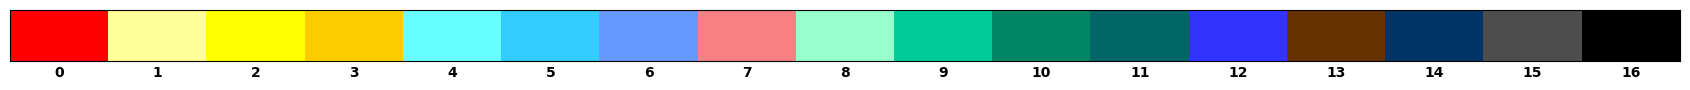

Palette specific to Ruhcp_CN:


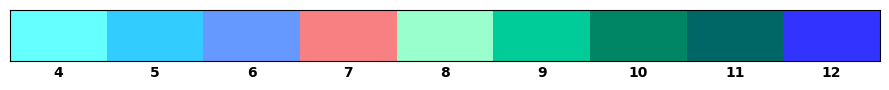

Jmol command:
color 'colorCN = [xFF0000] [xFFFF99] [xFFFF00] [xFFCC00] [x66FFFF] [x33CCFF] [x6699FF] [xF98082] [x99FFCC] [x00CC99] [x008665] [x006666] [x3333FF] [x663300] [x003366] [x4D4D4D] [x000000] ';
{*}.valence = load('Ruhcp_CN.dat'); color atoms property valence 'colorCN' RANGE 0 16 ;label %2.0[valence]; color label yellow ; font label 24 ; set labeloffset 7 0;


In [66]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

RuNP = cyNP.Crystal("Ru hcp",
                    shape='Wulff: hcpsph1',
                    noOutput=True,sizesWulff=[2],
                    threshold=1e-3,
                    thresholdCoreSurface=2,
                    postAnalyzis=True,
                    jmolCrystalShape=True,)
write("coords/Ruhcp.xyz", RuNP.NP)
pyNMBu.saveCN4JMol(RuNP.NP,save2="coords/Ruhcp_CN.dat",Rmax=3.0)

# Bibliography

<div class="intro">

Mori, T.; Hegmann, T. (**2016**) Determining the Composition of Gold Nanoparticles: A Compilation of Shapes, Sizes, and Calculations Using Geometric Considerations. *J. Nanopart. Res.* **18**(10): 295, [link](https://doi.org/10.1007/s11051-016-3587-7)

Kaatz, F. H.; Bultheel, A. (**2019**) Magic Mathematical Relationships for Nanoclusters. *Nanoscale Res. Lett.* **14**(1): 150, [link](https://doi.org/10.1186/s11671-019-2939-5)

[4D Euclidean space](https://www.qfbox.info/4d/)

[https://rechneronline.de/pi/](https://rechneronline.de/pi/)
</div>

# To do (UPDATED 20240608). Deadline Christmas 2024
(NB. general target is 20x20 nm x 100 nm dimensions with 5 to 10 nm seeds)

- SASview > pdb is needed(Nicolas RR has written an xyz>pdb translator, see also `pyMatGen`)
- ~add the calculation of *G** => interplanar spacing and **calculation of the indices of the normal direction to any crystallographic plane defined by its Miller indices**  (<u>it is the same only in the cubic crystals case</u>)~
- ~decahedra, Ino and Marks decahedra => 5-fold symmetry nanowires~ (20240520)
- cylinders along any (hkl) direction > *converted as n-fold rotation faceting*
    - ~cubic systems~
    - ~hcp~
    - ~6-fold symmetry nanowires (i.e. hcp)~ (ok only if it lies along the c axis)
    - other- 3, 4, 5, 6, 8 bipyramids with elongation factor along *c* : as magic numbers twinned nanocrystals ~or as Wulff shapes~
    - nanowire in any [h,k,l] direction with periodic boundary conditions
- starting from a seed, add growth along any hkl direction
    - cubic systems
    - hcp
    - other
- add seeds of another metal, just as an inner ellipsoid
- implements an efficient algorithm to identify surface and core atoms
    - ~convex hull is ok for crystals that do not exhibit steps~
    - go beyond convex hull first strategy
    - calculate CN and CNeff, plot with jmol as a 3D map
- ~ase/pbc > generates a fifth column > delete (done by Nicolas)~

- include I(q)
- add a gui

# End

In [95]:
pyNMB.end()

**End at:** Saturday 14 March 2026, 15:22:26  
**Duration:** 01:02:23 680ms

In [ ]:
from debyecalculator import DebyeCalculator
import torch
import numpy as np


def calcSofQ(xyzfile:str,qmin:float=1,qmax:float=25,qstep:float=0.01,biso:float=0.1,save=False):
    """
    xyz file: path to file produced by pyNMP- as this file contains 5 columns, it should be cleaned using the clean_xyz function
    qmin: min q value on which the Debye equation is computed
    qmax: max q value on which the Debye equation is computed
    qstep: step between successive q points
    biso: term for isotropic atomic displacement parameter
    """
    if torch.cuda.is_available():
        device='cuda'
    else:
        device='cpu'  
    calc = DebyeCalculator(qmin=qmin,qmax=qmax,qstep=qstep,device=device,biso=biso)
    Q, I =calc.iq(structure_source=xyzfile)
    # eventually add line to save data to file *.iq
    if save:
        filename=xyzfile.split('.')[:-1]+'_calc.iq'
        np.savetxt(filename,np.column_stack([Q,I]))
    return Q,I
    

def calcGofR(xyzfile:str,rmin:float=0,rmax:float=50,rstep:float=0.01,biso:float=0.1,qdamp:float=0,save=False):
    """
    xyz file: path to file produced by pyNMP- as this file contains 5 columns, it should be cleaned using the clean_xyz function
    qmin: min q value on which the Debye equation is computed
    qmax: max q value on which the Debye equation is computed
    qstep: step between successive q points
    biso: term for isotropic atomic displacement parameter
    qdamp: parameter to accune for PDF damping linked to truncation 
    """
    if torch.cuda.is_available():
        device='cuda'
    else:
        device='cpu'  
    calc = DebyeCalculator(rmin=rmin,rmax=rmax,rstep=rstep,device=device,biso=biso,qdamp=qdamp)
    r, G =calc.gr(structure_source=xyzfile)
    # eventually add line to save data to file *.gr
    if save:
        filename=xyzfile.split('.')[:-1]+'_calc.gr'
        np.savetxt(filename,np.column_stack([r,G]))
    return r,G 